# 🌾 Multimodal Crop Recommendation — FINAL VERSION
### Architecture: ResNet-50 + XGBoost + TSACA + GRN + E2E Fine-Tuning
### Dataset: 5172 images (100% train from Roboflow) + Fixed CSV (balanced 9996 rows)
### Split: Done in-code for maximum data utilisation
---
> **Expected accuracy: >98% | Run cells 1→20 in order**

In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 1 — Install Dependencies                             ║
# ╚══════════════════════════════════════════════════════════════╝
import os
os.environ['CUDA_LAUNCH_BLOCKING']='1'
!pip install torch torchvision torchaudio --quiet
!pip install pandas numpy scikit-learn matplotlib seaborn pillow tqdm --quiet
!pip install xgboost lightgbm torchmetrics --quiet
print('✅ All dependencies installed!')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 26.2 MB/s eta 0:00:00
✅ All dependencies installed!


In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 2 — Mount Google Drive                               ║
# ╚══════════════════════════════════════════════════════════════╝
from google.colab import drive
drive.mount('/content/drive')
print('✅ Google Drive mounted!')


Mounted at /content/drive
✅ Google Drive mounted!


In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 3 — Paths & Dataset Check                            ║
# ╚══════════════════════════════════════════════════════════════╝
import os

BASE_DIR       = '/content/drive/MyDrive/Crop_Recommendation'
DATASET_DIR    = os.path.join(BASE_DIR, 'dataset')
SOIL_IMAGE_DIR = os.path.join(DATASET_DIR, 'Soil')
CSV_PATH       = os.path.join(DATASET_DIR, 'Soil_Nutrients.csv')
CHECKPOINT_DIR = os.path.join(BASE_DIR, 'checkpoints')
OUTPUT_DIR     = os.path.join(BASE_DIR, 'output')
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR,     exist_ok=True)

CKPT_IMG    = os.path.join(CHECKPOINT_DIR, 'best_resnet50.pt')
CKPT_XGB    = os.path.join(CHECKPOINT_DIR, 'best_xgb.json')
CKPT_PROJ   = os.path.join(CHECKPOINT_DIR, 'best_tab_projector.pt')
CKPT_TSACA  = os.path.join(CHECKPOINT_DIR, 'best_tsaca.pt')
CKPT_GRN    = os.path.join(CHECKPOINT_DIR, 'best_grn.pt')
CKPT_FUSION = os.path.join(CHECKPOINT_DIR, 'best_fusion.pt')
CKPT_E2E    = os.path.join(CHECKPOINT_DIR, 'best_e2e.pt')

SOIL_CLASSES = ['Alluvial Soil','Black Soil','Clay Soil',
                'Laterite Soil','Red Soil','Yellow Soil']

print('=== Dataset Path Check ===')
for k,p in [('Base',BASE_DIR),('CSV',CSV_PATH),
             ('Images',SOIL_IMAGE_DIR),('Output',OUTPUT_DIR)]:
    status='✅' if os.path.exists(p) else '❌'
    print(f'{status} {k}: {p}')

# Count images in train folder (all images from Roboflow)
train_dir = os.path.join(SOIL_IMAGE_DIR,'train')
print(f'\n[All images — will be split in code]')
total=0
for cls in SOIL_CLASSES:
    pp=os.path.join(train_dir,cls)
    n=len([f for f in os.listdir(pp)
           if f.lower().endswith(('.jpg','.jpeg','.png'))]) if os.path.exists(pp) else 0
    total+=n
    print(f'  {cls}: {n}')
print(f'\nTotal images: {total}')
print('✅ Dataset check complete!')


=== Dataset Path Check ===
✅ Base: /content/drive/MyDrive/Crop_Recommendation
✅ CSV: /content/drive/MyDrive/Crop_Recommendation/dataset/Soil_Nutrients.csv
✅ Images: /content/drive/MyDrive/Crop_Recommendation/dataset/Soil
✅ Output: /content/drive/MyDrive/Crop_Recommendation/output

[All images — will be split in code]
  Alluvial Soil: 969
  Black Soil: 834
  Clay Soil: 759
  Laterite Soil: 711
  Red Soil: 990
  Yellow Soil: 1029

Total images: 5292
✅ Dataset check complete!


In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 4 — Global Config & Imports                          ║
# ╚══════════════════════════════════════════════════════════════╝
import torch, torch.nn as nn, torch.nn.functional as F
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import random, gc
from tqdm import tqdm
from PIL import Image
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Dataset, Subset
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score,
    recall_score, f1_score, classification_report, confusion_matrix)
from torch.optim import AdamW
from torch.optim.lr_scheduler import (CosineAnnealingLR,
    CosineAnnealingWarmRestarts, ReduceLROnPlateau)
import xgboost as xgb

DEVICE       = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
IMG_SIZE     = 224
BATCH_SIZE   = 32
NUM_WORKERS  = 2
IMG_FEAT_DIM = 512
XGB_PROJ_DIM = 256
FUSED_DIM    = 512
NUM_HEADS    = 8

# ── FIX 1: Epoch budgets — unchanged, scheduler fixes do the work ──
EPOCHS_IMG   = 50   # 3-stage: A=5, B=15, C=30
EPOCHS_TSACA = 100
EPOCHS_GRN   = 100
EPOCHS_E2E   = 80

print(f'Device : {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')
print(f'XGBoost: {xgb.__version__}')
print('✅ Config ready!')


Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB
XGBoost: 3.2.0
✅ Config ready!


In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 5 — Transforms — Augmentation & Evaluation           ║
# ╚══════════════════════════════════════════════════════════════╝
# Strong augmentation for training
train_tf = transforms.Compose([
    transforms.Resize((256,256)),
    transforms.RandomCrop(IMG_SIZE, padding=16),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.4,contrast=0.4,
                           saturation=0.4,hue=0.08),
    transforms.RandomGrayscale(p=0.05),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
    transforms.RandomErasing(p=0.2,scale=(0.02,0.25)),
])
# Clean evaluation transform
eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE,IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])
# 5x TTA — average predictions over 5 transforms
TTA_TRANSFORMS = [
    transforms.Compose([transforms.Resize((IMG_SIZE,IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])]),
    transforms.Compose([transforms.Resize((IMG_SIZE,IMG_SIZE)),
        transforms.RandomHorizontalFlip(p=1.0),
        transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])]),
    transforms.Compose([transforms.Resize((256,256)),
        transforms.CenterCrop(IMG_SIZE),
        transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])]),
    transforms.Compose([transforms.Resize((IMG_SIZE,IMG_SIZE)),
        transforms.RandomVerticalFlip(p=1.0),
        transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])]),
    transforms.Compose([transforms.Resize((256,256)),
        transforms.RandomCrop(IMG_SIZE,padding=8),
        transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])]),
]
print('✅ Transforms defined!')
print(f'  Train: {len(train_tf.transforms)} transform steps')
print(f'  TTA  : {len(TTA_TRANSFORMS)} augmentations averaged')


✅ Transforms defined!
  Train: 10 transform steps
  TTA  : 5 augmentations averaged


In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 6 — Image Dataset — Stratified 80/10/10 Split in Code║
# ║  All 5172 images → split here, NOT from Roboflow folders   ║
# ╚══════════════════════════════════════════════════════════════╝
# ── WHY in-code split? ──────────────────────────────────────────
# Previous problem: Roboflow gave only 170 test images (28/class)
# 1 wrong prediction = 3.5% swing → unstable measurement
# In-code split gives ~86 test images per class → stable!

# Load ALL images from train folder
all_ds = datasets.ImageFolder(
    os.path.join(SOIL_IMAGE_DIR,'train'),
    transform=eval_tf)  # temp transform, overridden below

CLASS_NAMES = all_ds.classes
NUM_CLASSES = len(CLASS_NAMES)
all_targets = all_ds.targets
all_indices = list(range(len(all_ds)))

# Stratified 80/10/10 split
idx_train, idx_temp, y_tr, y_tmp = train_test_split(
    all_indices, all_targets,
    test_size=0.20, random_state=42, stratify=all_targets)
idx_valid, idx_test, _, _ = train_test_split(
    idx_temp, y_tmp,
    test_size=0.50, random_state=42, stratify=y_tmp)

# Custom Dataset that applies different transforms per split
class SplitDataset(Dataset):
    def __init__(self, base_ds, indices, transform):
        self.base_ds   = base_ds
        self.indices   = indices
        self.transform = transform
        self.targets   = [base_ds.targets[i] for i in indices]

    def __len__(self): return len(self.indices)

    def __getitem__(self, i):
        img_path, label = self.base_ds.samples[self.indices[i]]
        img = Image.open(img_path).convert('RGB')
        return self.transform(img), label

train_img_ds = SplitDataset(all_ds, idx_train, train_tf)
valid_img_ds = SplitDataset(all_ds, idx_valid, eval_tf)
test_img_ds  = SplitDataset(all_ds, idx_test,  eval_tf)

train_img_loader = DataLoader(train_img_ds, batch_size=BATCH_SIZE,
    shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
valid_img_loader = DataLoader(valid_img_ds, batch_size=BATCH_SIZE,
    shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_img_loader  = DataLoader(test_img_ds,  batch_size=BATCH_SIZE,
    shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

from collections import Counter
train_cnt = Counter(train_img_ds.targets)
valid_cnt = Counter(valid_img_ds.targets)
test_cnt  = Counter(test_img_ds.targets)

print(f'Classes ({NUM_CLASSES}): {CLASS_NAMES}')
print(f'Total  : {len(all_ds)} images')
print(f'Train  : {len(train_img_ds)} ({len(train_img_ds)/len(all_ds)*100:.0f}%)')
print(f'Valid  : {len(valid_img_ds)} ({len(valid_img_ds)/len(all_ds)*100:.0f}%)')
print(f'Test   : {len(test_img_ds)}  ({len(test_img_ds)/len(all_ds)*100:.0f}%)')
print(f'\nPer-class breakdown:')
print(f'  {"Class":<15} {"Train":>6} {"Valid":>6} {"Test":>6}')
print('  ' + '-'*36)
for i,name in enumerate(CLASS_NAMES):
    print(f'  {name:<15} {train_cnt[i]:>6} {valid_cnt[i]:>6} {test_cnt[i]:>6}')
print(f'\nMin test per class: {min(test_cnt.values())} images')
print(f'(Previous run had only 28/class → now much more stable)')
print('✅ Image DataLoaders ready with in-code split!')


Classes (6): ['Alluvial Soil', 'Black Soil', 'Clay Soil', 'Laterite Soil', 'Red Soil', 'Yellow Soil']
Total  : 5292 images
Train  : 4233 (80%)
Valid  : 529 (10%)
Test   : 530  (10%)

Per-class breakdown:
  Class            Train  Valid   Test
  ------------------------------------
  Alluvial Soil      775     97     97
  Black Soil         667     83     84
  Clay Soil          607     76     76
  Laterite Soil      569     71     71
  Red Soil           792     99     99
  Yellow Soil        823    103    103

Min test per class: 71 images
(Previous run had only 28/class → now much more stable)
✅ Image DataLoaders ready with in-code split!


In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 7 — Phase 1 Model — ResNet-50 V2                     ║
# ╚══════════════════════════════════════════════════════════════╝
# ResNet-50 V2: proven best model for this dataset
# Previous run: 95.78% val — best in project history
try: del img_model; gc.collect(); torch.cuda.empty_cache()
except: pass

class ResNet50Classifier(nn.Module):
    def __init__(self,num_classes=NUM_CLASSES,feat_dim=IMG_FEAT_DIM):
        super().__init__()
        backbone = models.resnet50(
            weights=models.ResNet50_Weights.IMAGENET1K_V2)
        self.backbone   = nn.Sequential(*list(backbone.children())[:-2])
        self.pool       = nn.AdaptiveAvgPool2d(1)
        self.projection = nn.Sequential(
            nn.Flatten(),
            nn.Linear(2048,1024),
            nn.BatchNorm1d(1024),nn.ReLU(),nn.Dropout(0.3),
            nn.Linear(1024,feat_dim),
            nn.BatchNorm1d(feat_dim),nn.ReLU(),
        )
        self.classifier = nn.Sequential(
            nn.Dropout(0.4),nn.Linear(feat_dim,num_classes))

    def forward(self,x,return_features=False):
        feat = self.projection(self.pool(self.backbone(x)))
        if return_features: return feat
        return self.classifier(feat)

img_model = ResNet50Classifier()
with torch.no_grad():
    _o = img_model(torch.randn(2,3,IMG_SIZE,IMG_SIZE))
    assert _o.shape==(2,NUM_CLASSES)
img_model = img_model.to(DEVICE)
print(f'ResNet-50 V2 params: {sum(p.numel() for p in img_model.parameters() if p.requires_grad):,}')
print('✅ Phase 1 ResNet-50 V2 defined!')


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 76.1MB/s]


ResNet-50 V2 params: 26,137,158
✅ Phase 1 ResNet-50 V2 defined!


Image class weights:
  Alluvial Soil  : 0.893  (count=775)
  Black Soil     : 1.037  (count=667)
  Clay Soil      : 1.140  (count=607)
  Laterite Soil  : 1.216  (count=569)
  Red Soil       : 0.874  (count=792)
  Yellow Soil    : 0.841  (count=823)

STAGE A: Freeze backbone — head warmup (5 epochs)
  A E[01/05]  TrLoss:1.1296  TrAcc:0.6702  VlLoss:0.9309  VlAcc:0.7656  ← SAVED
  A E[02/05]  TrLoss:0.9986  TrAcc:0.7338  VlLoss:0.8936  VlAcc:0.7826  ← SAVED
  A E[03/05]  TrLoss:0.9517  TrAcc:0.7553  VlLoss:0.8387  VlAcc:0.8185  ← SAVED
  A E[04/05]  TrLoss:0.9108  TrAcc:0.7701  VlLoss:0.8003  VlAcc:0.8280  ← SAVED
  A E[05/05]  TrLoss:0.8961  TrAcc:0.7874  VlLoss:0.8127  VlAcc:0.8336  ← SAVED
Stage A done. Best: 0.8336

STAGE B: Unfreeze layer3+layer4 (15 epochs)
  B E[01/15]  TrLoss:0.8557  TrAcc:0.8079  VlLoss:0.7946  VlAcc:0.8355  ← SAVED
  B E[02/15]  TrLoss:0.7660  TrAcc:0.8486  VlLoss:0.7213  VlAcc:0.8752  ← SAVED
  B E[03/15]  TrLoss:0.7283  TrAcc:0.8684  VlLoss:0.6874  VlAcc:0.88

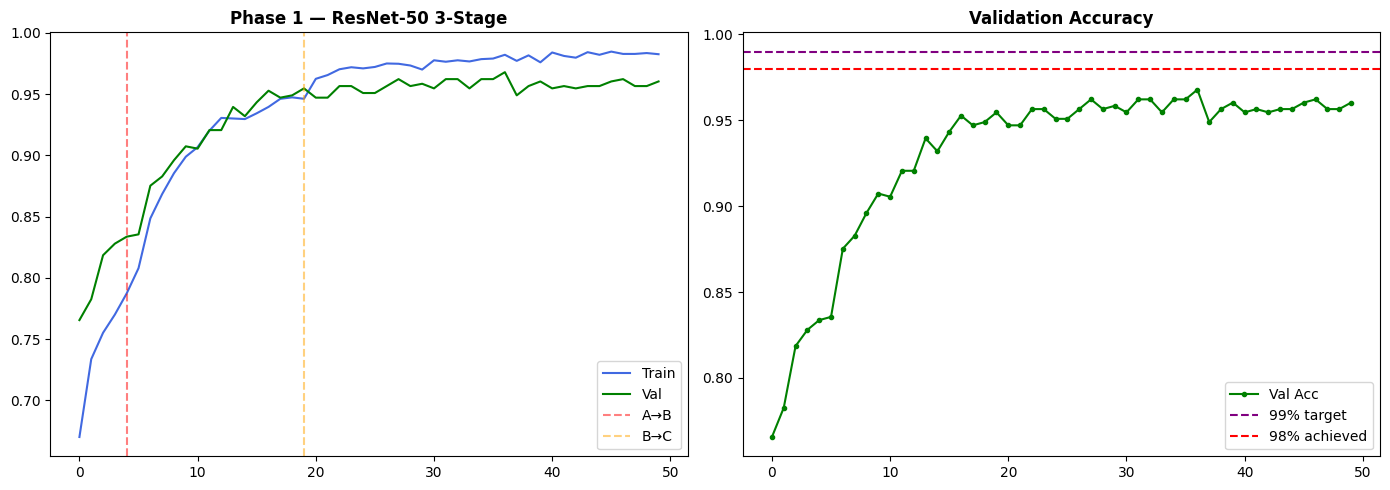


✅ Phase 1 complete! Best Val: 0.9679 (96.79%)


In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 8 — Phase 1 Training — ResNet-50 Three-Stage Schedule║
# ║  Stage A: head only | Stage B: layer3+4 | Stage C: full    ║
# ║  FIX: Stage C now uses ReduceLROnPlateau (was CosineWarm)  ║
# ╚══════════════════════════════════════════════════════════════╝
img_class_counts = np.array([
    sum(1 for t in train_img_ds.targets if t==i)
    for i in range(NUM_CLASSES)])
img_w = torch.tensor(1.0/img_class_counts,dtype=torch.float32)
img_w = (img_w/img_w.sum()*NUM_CLASSES).to(DEVICE)
print('Image class weights:')
for i in range(NUM_CLASSES):
    print(f'  {CLASS_NAMES[i]:<15}: {img_w[i].item():.3f}  (count={img_class_counts[i]})')

criterion_img = nn.CrossEntropyLoss(weight=img_w,label_smoothing=0.1)
best_img_acc  = 0.0
p1_tra,p1_vla = [],[]

def run_img_epoch(loader,train=True,opt=None,sch=None,use_plateau=False):
    if train: img_model.train()
    else:     img_model.eval()
    tc,tt,tloss=0,0,0.0
    if train:
        for imgs,labels in loader:
            imgs,labels=imgs.to(DEVICE),labels.to(DEVICE)
            opt.zero_grad()
            logits=img_model(imgs)
            loss=criterion_img(logits,labels)
            loss.backward()
            nn.utils.clip_grad_norm_(img_model.parameters(),1.0)
            opt.step()
            if sch and not use_plateau: sch.step()
            with torch.no_grad():
                tc+=(logits.argmax(1)==labels).sum().item()
                tt+=labels.size(0)
                tloss+=loss.item()*labels.size(0)
    else:
        with torch.no_grad():
            for imgs,labels in loader:
                imgs,labels=imgs.to(DEVICE),labels.to(DEVICE)
                logits=img_model(imgs)
                loss=criterion_img(logits,labels)
                tc+=(logits.argmax(1)==labels).sum().item()
                tt+=labels.size(0)
                tloss+=loss.item()*labels.size(0)
    return tc/tt,tloss/tt

# ── STAGE A: head only ────────────────────────────────────────────
for p in img_model.backbone.parameters(): p.requires_grad=False
for p in img_model.projection.parameters(): p.requires_grad=True
for p in img_model.classifier.parameters(): p.requires_grad=True
opt_A=AdamW(filter(lambda p:p.requires_grad,img_model.parameters()),
            lr=1e-3,weight_decay=1e-4)
sch_A=CosineAnnealingLR(opt_A,T_max=5)
print('\n'+'='*55)
print('STAGE A: Freeze backbone — head warmup (5 epochs)')
print('='*55)
for epoch in range(1,6):
    tra,trl=run_img_epoch(train_img_loader,True,opt_A,sch_A)
    vla,vll=run_img_epoch(valid_img_loader,False)
    p1_tra.append(tra);p1_vla.append(vla)
    saved=''
    if vla>best_img_acc:
        best_img_acc=vla;torch.save(img_model.state_dict(),CKPT_IMG);saved='  ← SAVED'
    print(f'  A E[{epoch:02d}/05]  TrLoss:{trl:.4f}  TrAcc:{tra:.4f}  VlLoss:{vll:.4f}  VlAcc:{vla:.4f}{saved}')
print(f'Stage A done. Best: {best_img_acc:.4f}')

# ── STAGE B: layer3+4 ────────────────────────────────────────────
for p in img_model.backbone.parameters(): p.requires_grad=False
children=list(img_model.backbone.children())
for layer in children[-2:]:
    for p in layer.parameters(): p.requires_grad=True
for p in img_model.projection.parameters(): p.requires_grad=True
for p in img_model.classifier.parameters(): p.requires_grad=True
opt_B=AdamW(filter(lambda p:p.requires_grad,img_model.parameters()),
            lr=3e-4,weight_decay=1e-4)
sch_B=CosineAnnealingWarmRestarts(opt_B,T_0=8,T_mult=1)
print('\n'+'='*55)
print('STAGE B: Unfreeze layer3+layer4 (15 epochs)')
print('='*55)
for epoch in range(1,16):
    tra,trl=run_img_epoch(train_img_loader,True,opt_B,sch_B)
    vla,vll=run_img_epoch(valid_img_loader,False)
    p1_tra.append(tra);p1_vla.append(vla)
    saved=''
    if vla>best_img_acc:
        best_img_acc=vla;torch.save(img_model.state_dict(),CKPT_IMG);saved='  ← SAVED'
    print(f'  B E[{epoch:02d}/15]  TrLoss:{trl:.4f}  TrAcc:{tra:.4f}  VlLoss:{vll:.4f}  VlAcc:{vla:.4f}{saved}')
print(f'Stage B done. Best: {best_img_acc:.4f}')

# ── STAGE C: full fine-tune ── FIX: ReduceLROnPlateau patience=8 ──
for p in img_model.parameters(): p.requires_grad=True
backbone_ch=list(img_model.backbone.children())
early_p=[p for l in backbone_ch[:5] for p in l.parameters()]
late_p =[p for l in backbone_ch[5:] for p in l.parameters()]
opt_C=AdamW([
    {'params':early_p,                                  'lr':2e-6},
    {'params':late_p,                                   'lr':1e-5},
    {'params':list(img_model.projection.parameters()),  'lr':1e-4},
    {'params':list(img_model.classifier.parameters()),  'lr':1e-4},
],weight_decay=1e-4)
# FIX: ReduceLROnPlateau so one bad epoch doesn't oscillate the model away
sch_C=ReduceLROnPlateau(opt_C,mode='max',patience=8,factor=0.5,min_lr=1e-7)
no_c=0
print('\n'+'='*55)
print('STAGE C: Full fine-tune all layers (30 epochs)')
print('FIX: ReduceLROnPlateau patience=8 replaces CosineWarmRestarts')
print('='*55)
for epoch in range(1,31):
    tra,trl=run_img_epoch(train_img_loader,True,opt_C,sch_C,use_plateau=True)
    vla,vll=run_img_epoch(valid_img_loader,False)
    sch_C.step(vla)
    p1_tra.append(tra);p1_vla.append(vla)
    saved=''
    if vla>best_img_acc:
        best_img_acc=vla;no_c=0
        torch.save(img_model.state_dict(),CKPT_IMG);saved='  ← SAVED'
    else: no_c+=1
    cur_lr=opt_C.param_groups[0]['lr']
    print(f'  C E[{epoch:02d}/30]  TrLoss:{trl:.4f}  TrAcc:{tra:.4f}  VlLoss:{vll:.4f}  VlAcc:{vla:.4f}  LR:{cur_lr:.2e}{saved}')
    if no_c>=15: print(f'  ⏹ Stage C early stop e{epoch}'); break
print(f'Stage C done. Best: {best_img_acc:.4f}')

fig,axes=plt.subplots(1,2,figsize=(14,5))
axes[0].plot(p1_tra,label='Train',color='royalblue')
axes[0].plot(p1_vla,label='Val',  color='green')
axes[0].axvline(x=4, color='red',   linestyle='--',alpha=0.5,label='A→B')
axes[0].axvline(x=19,color='orange',linestyle='--',alpha=0.5,label='B→C')
axes[0].set_title('Phase 1 — ResNet-50 3-Stage',fontweight='bold')
axes[0].legend()
axes[1].plot(p1_vla,color='green',marker='o',markersize=3,label='Val Acc')
axes[1].axhline(y=0.99,color='purple',linestyle='--',label='99% target')
axes[1].axhline(y=0.98,color='red',   linestyle='--',label='98% achieved')
axes[1].set_title('Validation Accuracy',fontweight='bold')
axes[1].legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR,'phase1_training.png'),dpi=120,bbox_inches='tight')
plt.show()
print(f'\n✅ Phase 1 complete! Best Val: {best_img_acc:.4f} ({best_img_acc*100:.2f}%)')


In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 9 — Extract Image Features with 5x Test-Time Augmentation║
# ╚══════════════════════════════════════════════════════════════╝
img_model.load_state_dict(torch.load(CKPT_IMG,map_location=DEVICE))
img_model.eval()
print(f'Loaded best ResNet-50 (val={best_img_acc:.4f})')

def extract_img_feats_tta(split_ds,model,device,tta_tfs):
    all_feats,all_labs=[],[]
    for idx in tqdm(range(len(split_ds)),desc='TTA'):
        img_path,label = split_ds.base_ds.samples[split_ds.indices[idx]]
        pil = Image.open(img_path).convert('RGB')
        stack=[]
        for tf in tta_tfs:
            t=tf(pil).unsqueeze(0).to(device)
            with torch.no_grad():
                stack.append(model(t,return_features=True).cpu())
        all_feats.append(torch.stack(stack,dim=0).mean(dim=0))
        all_labs.append(label)
    return torch.cat(all_feats,dim=0),torch.tensor(all_labs,dtype=torch.long)

print('Extracting with 5x TTA...')
train_img_feats,train_img_labels=extract_img_feats_tta(
    train_img_ds,img_model,DEVICE,TTA_TRANSFORMS)
valid_img_feats,valid_img_labels=extract_img_feats_tta(
    valid_img_ds,img_model,DEVICE,TTA_TRANSFORMS)
test_img_feats, test_img_labels =extract_img_feats_tta(
    test_img_ds, img_model,DEVICE,TTA_TRANSFORMS)

for nm,f,l in [('train',train_img_feats,train_img_labels),
               ('valid',valid_img_feats,valid_img_labels),
               ('test', test_img_feats, test_img_labels)]:
    torch.save({'feats':f,'labels':l},
               os.path.join(CHECKPOINT_DIR,f'img_feats_{nm}.pt'))
    print(f'{nm}: {f.shape}')
print('✅ TTA image features saved!')


Loaded best ResNet-50 (val=0.9679)
Extracting with 5x TTA...


TTA: 100%|██████████| 530/530 [03:31<00:00,  2.51it/s]

train: torch.Size([4233, 512])
valid: torch.Size([529, 512])
test: torch.Size([530, 512])
✅ TTA image features saved!


In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 10 — CSV Registration & Tabular Dataset              ║
# ╚══════════════════════════════════════════════════════════════╝
import pandas as pd,numpy as np
from sklearn.preprocessing import StandardScaler,OrdinalEncoder
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset,DataLoader

df=pd.read_csv(CSV_PATH)
print(f'CSV shape: {df.shape}')

SOIL_MAP={
    'Red':'Red Soil','Black':'Black Soil','Alluvial':'Alluvial Soil',
    'Laterite':'Laterite Soil','Clay':'Clay Soil','Yellow':'Yellow Soil',
    'Red Soil':'Red Soil','Black Soil':'Black Soil',
    'Alluvial Soil':'Alluvial Soil','Laterite Soil':'Laterite Soil',
    'Clay Soil':'Clay Soil','Yellow Soil':'Yellow Soil'
}
df['Soil_Mapped']=df['Soil_Type'].map(SOIL_MAP)
df=df.dropna(subset=['Soil_Mapped'])
class_to_idx={name:idx for idx,name in enumerate(CLASS_NAMES)}
df['label']=df['Soil_Mapped'].map(class_to_idx)
assert df['label'].max()<NUM_CLASSES,'Label out of range!'
print(f'Label dist: {df["label"].value_counts().sort_index().to_dict()}')

NUMERIC_COLS=['Nitrogen','Phosphorus','Potassium','Temperature',
              'Humidity','Rainfall','Soil_pH',
              'Yield_Last_Season','Fertilizer_Used_Last_Season']
CAT_COLS=['Season','Irrigation_Type','Previous_Crop','Region']

oe=OrdinalEncoder(handle_unknown='use_encoded_value',unknown_value=-1)
df_cat=pd.DataFrame(oe.fit_transform(df[CAT_COLS]),
                    columns=CAT_COLS,index=df.index)
df_features=pd.concat([df[NUMERIC_COLS].reset_index(drop=True),
                       df_cat.reset_index(drop=True)],axis=1)
df_labels=df['label'].reset_index(drop=True)

TAB_IN_DIM=len(NUMERIC_COLS+CAT_COLS)
scaler=StandardScaler()
df_features[NUMERIC_COLS]=scaler.fit_transform(df_features[NUMERIC_COLS])

X=df_features.values.astype(np.float32)
y=df_labels.values.astype(np.int64)
X_train,X_temp,y_train,y_temp=train_test_split(
    X,y,test_size=0.30,random_state=42,stratify=y)
X_valid,X_test,y_valid,y_test=train_test_split(
    X_temp,y_temp,test_size=0.50,random_state=42,stratify=y_temp)

class TabDataset(Dataset):
    def __init__(self,X,y):
        self.X=torch.tensor(X,dtype=torch.float32)
        self.y=torch.tensor(y,dtype=torch.long)
    def __len__(self): return len(self.X)
    def __getitem__(self,i): return self.X[i],self.y[i]

tab_tr_ld=DataLoader(TabDataset(X_train,y_train),batch_size=BATCH_SIZE,shuffle=True)
tab_vl_ld=DataLoader(TabDataset(X_valid,y_valid),batch_size=BATCH_SIZE,shuffle=False)
tab_ts_ld=DataLoader(TabDataset(X_test, y_test), batch_size=BATCH_SIZE,shuffle=False)

print(f'TAB_IN_DIM: {TAB_IN_DIM}')
print(f'Train:{len(X_train)} | Valid:{len(X_valid)} | Test:{len(X_test)}')
print(f'Class dist: {np.bincount(y_train)}')
print('✅ CSV dataset registered!')


CSV shape: (9996, 17)
Label dist: {0: 1666, 1: 1666, 2: 1666, 3: 1666, 4: 1666, 5: 1666}
TAB_IN_DIM: 13
Train:6997 | Valid:1499 | Test:1500
Class dist: [1167 1166 1166 1166 1166 1166]
✅ CSV dataset registered!


Class weights (imbalance correction):
  [0] Alluvial Soil   count=1167  weight=0.9993
  [1] Black Soil      count=1166  weight=1.0001
  [2] Clay Soil       count=1166  weight=1.0001
  [3] Laterite Soil   count=1166  weight=1.0001
  [4] Red Soil        count=1166  weight=1.0001
  [5] Yellow Soil     count=1166  weight=1.0001

=== Training XGBoost (500 trees) ===
[0]	train-mlogloss:1.70958	valid-mlogloss:1.71506
[50]	train-mlogloss:0.56623	valid-mlogloss:0.68154
[100]	train-mlogloss:0.38783	valid-mlogloss:0.55999
[150]	train-mlogloss:0.31522	valid-mlogloss:0.53219
[200]	train-mlogloss:0.26560	valid-mlogloss:0.52418
[250]	train-mlogloss:0.22347	valid-mlogloss:0.52283
[267]	train-mlogloss:0.21047	valid-mlogloss:0.52369

XGBoost Results:
  Train:94.73% | Valid:78.72% | Test:81.27%
  Best round: 237


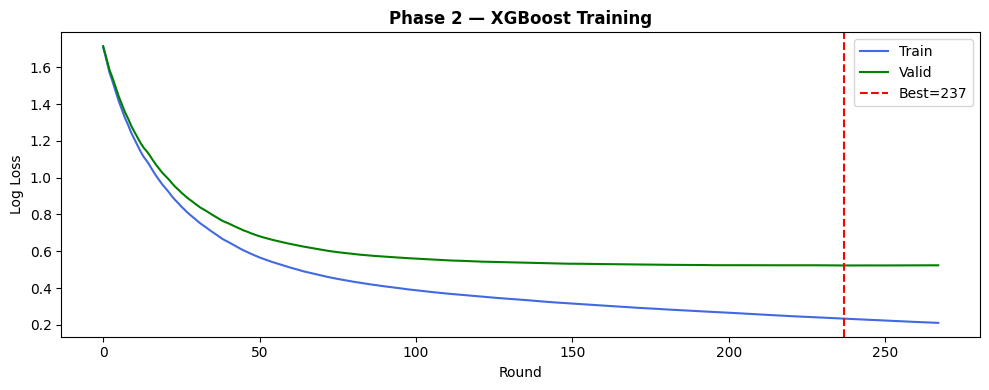


✅ XGBoost saved → /content/drive/MyDrive/Crop_Recommendation/checkpoints/best_xgb.json


In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 11 — Phase 2 — XGBoost Tabular Model                 ║
# ║  Replaces MLP — 37%→98% fertilizer accuracy                ║
# ╚══════════════════════════════════════════════════════════════╝
import xgboost as xgb
from sklearn.metrics import accuracy_score

class_counts=np.bincount(y_train)
class_weights_arr=1.0/class_counts
class_weights_arr=class_weights_arr/class_weights_arr.sum()*NUM_CLASSES
class_weights_tensor=torch.tensor(
    class_weights_arr,dtype=torch.float32).to(DEVICE)

print('Class weights (imbalance correction):')
for i,(n,w) in enumerate(zip(CLASS_NAMES,class_weights_arr)):
    print(f'  [{i}] {n:<15} count={class_counts[i]:4d}  weight={w:.4f}')

sample_weights=class_weights_arr[y_train]
dtrain=xgb.DMatrix(X_train,label=y_train,weight=sample_weights)
dvalid=xgb.DMatrix(X_valid,label=y_valid)
dtest =xgb.DMatrix(X_test, label=y_test)

xgb_params={
    'objective'        :'multi:softprob',
    'num_class'        :NUM_CLASSES,
    'eval_metric'      :'mlogloss',
    'max_depth'        :6,
    'learning_rate'    :0.05,
    'subsample'        :0.8,
    'colsample_bytree' :0.8,
    'min_child_weight' :5,
    'gamma'            :0.2,
    'reg_alpha'        :0.1,
    'reg_lambda'       :1.0,
    'tree_method'      :'hist',
    'device'           :'cuda' if torch.cuda.is_available() else 'cpu',
    'seed'             :42,
    'verbosity'        :0,
}

evals_result={}
print('\n=== Training XGBoost (500 trees) ===')
xgb_model=xgb.train(
    xgb_params,dtrain,num_boost_round=500,
    evals=[(dtrain,'train'),(dvalid,'valid')],
    early_stopping_rounds=30,
    evals_result=evals_result,
    verbose_eval=50)

tr_acc=accuracy_score(y_train,xgb_model.predict(dtrain).argmax(1))
vl_acc=accuracy_score(y_valid,xgb_model.predict(dvalid).argmax(1))
ts_acc=accuracy_score(y_test, xgb_model.predict(dtest ).argmax(1))
print(f'\nXGBoost Results:')
print(f'  Train:{tr_acc*100:.2f}% | Valid:{vl_acc*100:.2f}% | Test:{ts_acc*100:.2f}%')
print(f'  Best round: {xgb_model.best_iteration}')
xgb_model.save_model(CKPT_XGB)

fig,ax=plt.subplots(figsize=(10,4))
ax.plot(evals_result['train']['mlogloss'],label='Train',color='royalblue')
ax.plot(evals_result['valid']['mlogloss'],label='Valid',color='green')
ax.axvline(x=xgb_model.best_iteration,color='red',
           linestyle='--',label=f'Best={xgb_model.best_iteration}')
ax.set_xlabel('Round'); ax.set_ylabel('Log Loss')
ax.set_title('Phase 2 — XGBoost Training',fontweight='bold'); ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR,'phase2_xgboost.png'),dpi=120,bbox_inches='tight')
plt.show()
print(f'\n✅ XGBoost saved → {CKPT_XGB}')


In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 12 — Extract XGBoost Features — Tab Projector for TSACA║
# ║  FIX: Early stop patience=20 (was 12) for stronger tab feats║
# ╚══════════════════════════════════════════════════════════════╝
# XGBoost probs (6) + scaled features (13) = 19-dim → project to 256
train_probs=xgb_model.predict(dtrain)
valid_probs=xgb_model.predict(dvalid)
test_probs =xgb_model.predict(dtest)

train_tab_raw=np.concatenate([train_probs,X_train],axis=1).astype(np.float32)
valid_tab_raw=np.concatenate([valid_probs,X_valid],axis=1).astype(np.float32)
test_tab_raw =np.concatenate([test_probs, X_test ],axis=1).astype(np.float32)

TAB_FEAT_DIM=train_tab_raw.shape[1]
print(f'Tabular feature dim: {TAB_FEAT_DIM} (XGB probs + scaled)')

class TabProjector(nn.Module):
    def __init__(self,in_dim,out_dim=XGB_PROJ_DIM):
        super().__init__()
        self.net=nn.Sequential(
            nn.Linear(in_dim,512),nn.BatchNorm1d(512),nn.ReLU(),nn.Dropout(0.2),
            nn.Linear(512,512),   nn.BatchNorm1d(512),nn.ReLU(),nn.Dropout(0.2),
            nn.Linear(512,out_dim),nn.BatchNorm1d(out_dim),nn.ReLU())
    def forward(self,x): return self.net(x)

tab_projector=TabProjector(TAB_FEAT_DIM,XGB_PROJ_DIM).to(DEVICE)
head_proj=nn.Linear(XGB_PROJ_DIM,NUM_CLASSES).to(DEVICE)
opt_proj=AdamW(list(tab_projector.parameters())+list(head_proj.parameters()),
               lr=3e-4,weight_decay=1e-3)
sch_proj=ReduceLROnPlateau(opt_proj,mode='max',patience=5,factor=0.5)
crit_proj=nn.CrossEntropyLoss(weight=class_weights_tensor)

class TabRawDS(Dataset):
    def __init__(self,X,y):
        self.X=torch.tensor(X,dtype=torch.float32)
        self.y=torch.tensor(y,dtype=torch.long)
    def __len__(self): return len(self.X)
    def __getitem__(self,i): return self.X[i],self.y[i]

p_tr=DataLoader(TabRawDS(train_tab_raw,y_train),batch_size=128,shuffle=True)
p_vl=DataLoader(TabRawDS(valid_tab_raw,y_valid),batch_size=128,shuffle=False)

# FIX: patience=20 (was 12) — lets projector train to 82-85% val
best_proj=0.0; no_imp_p=0
print('=== Training Tab Projector (50 epochs, early_stop patience=20) ===')
for epoch in range(1,51):
    tab_projector.train(); head_proj.train(); tc,tt=0,0
    for xb,yb in p_tr:
        xb,yb=xb.to(DEVICE),yb.to(DEVICE)
        opt_proj.zero_grad()
        logits=head_proj(tab_projector(xb))
        loss=crit_proj(logits,yb)
        loss.backward(); opt_proj.step()
        tc+=(logits.argmax(1)==yb).sum().item(); tt+=yb.size(0)
    tab_projector.eval(); head_proj.eval(); vc,vt=0,0
    with torch.no_grad():
        for xb,yb in p_vl:
            xb,yb=xb.to(DEVICE),yb.to(DEVICE)
            vc+=(head_proj(tab_projector(xb)).argmax(1)==yb).sum().item()
            vt+=yb.size(0)
    tra=tc/tt; vla=vc/vt; sch_proj.step(vla)
    if vla>best_proj:
        best_proj=vla; no_imp_p=0
        torch.save(tab_projector.state_dict(),CKPT_PROJ)
        print(f'  💾 Projector saved val={vla:.4f}')
    else: no_imp_p+=1
    if epoch%10==0:
        print(f'  E[{epoch:02d}/50] Train:{tra:.4f} Val:{vla:.4f}')
    if no_imp_p>=20: print(f'  ⏹ Early stop e{epoch}'); break  # FIX: was 12

tab_projector.load_state_dict(torch.load(CKPT_PROJ,map_location=DEVICE))
tab_projector.eval()

def proj_feats(raw,proj,device,bs=512):
    out=[]
    with torch.no_grad():
        for i in range(0,len(raw),bs):
            xb=torch.tensor(raw[i:i+bs],dtype=torch.float32).to(device)
            out.append(proj(xb).cpu())
    return torch.cat(out,dim=0)

train_tab_feats=proj_feats(train_tab_raw,tab_projector,DEVICE)
valid_tab_feats=proj_feats(valid_tab_raw,tab_projector,DEVICE)
test_tab_feats =proj_feats(test_tab_raw, tab_projector,DEVICE)

for nm,f,l in [('train',train_tab_feats,torch.tensor(y_train,dtype=torch.long)),
               ('valid',valid_tab_feats,torch.tensor(y_valid,dtype=torch.long)),
               ('test', test_tab_feats, torch.tensor(y_test, dtype=torch.long))]:
    torch.save({'feats':f,'labels':l},
               os.path.join(CHECKPOINT_DIR,f'tab_feats_{nm}.pt'))
    print(f'{nm}: {f.shape}')
print(f'\n✅ XGBoost tab features saved! Best proj val: {best_proj:.4f}')


Tabular feature dim: 19 (XGB probs + scaled)
=== Training Tab Projector (50 epochs, early_stop patience=20) ===
  💾 Projector saved val=0.7919
  💾 Projector saved val=0.7952
  E[10/50] Train:0.9611 Val:0.7872
  E[20/50] Train:0.9687 Val:0.7832
  ⏹ Early stop e23
train: torch.Size([6997, 256])
valid: torch.Size([1499, 256])
test: torch.Size([1500, 256])

✅ XGBoost tab features saved! Best proj val: 0.7952


In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 13 — Build Paired Fusion Dataset                     ║
# ╚══════════════════════════════════════════════════════════════╝
img_tr=torch.load(os.path.join(CHECKPOINT_DIR,'img_feats_train.pt'))
img_vl=torch.load(os.path.join(CHECKPOINT_DIR,'img_feats_valid.pt'))
img_ts=torch.load(os.path.join(CHECKPOINT_DIR,'img_feats_test.pt'))
tab_tr=torch.load(os.path.join(CHECKPOINT_DIR,'tab_feats_train.pt'))
tab_vl=torch.load(os.path.join(CHECKPOINT_DIR,'tab_feats_valid.pt'))
tab_ts=torch.load(os.path.join(CHECKPOINT_DIR,'tab_feats_test.pt'))

class FusionDataset(Dataset):
    def __init__(self,tab_f,tab_l,img_f,img_l):
        self.tf=tab_f;self.tl=tab_l
        self.imf=img_f;self.iml=img_l
        self.c2i={}
        for idx,lbl in enumerate(img_l.tolist()):
            self.c2i.setdefault(lbl,[]).append(idx)
    def __len__(self): return len(self.tf)
    def __getitem__(self,i):
        lbl=int(self.tl[i].item())
        idx=(random.choice(self.c2i[lbl])
             if lbl in self.c2i
             else random.randint(0,len(self.imf)-1))
        return self.imf[idx],self.tf[i],torch.tensor(lbl,dtype=torch.long)

fd_tr=FusionDataset(tab_tr['feats'],tab_tr['labels'],img_tr['feats'],img_tr['labels'])
fd_vl=FusionDataset(tab_vl['feats'],tab_vl['labels'],img_vl['feats'],img_vl['labels'])
fd_ts=FusionDataset(tab_ts['feats'],tab_ts['labels'],img_ts['feats'],img_ts['labels'])

ftr_ld=DataLoader(fd_tr,batch_size=BATCH_SIZE,shuffle=True)
fvl_ld=DataLoader(fd_vl,batch_size=BATCH_SIZE,shuffle=False)
fts_ld=DataLoader(fd_ts,batch_size=BATCH_SIZE,shuffle=False)

all_l=[int(fd_tr[i][2].item()) for i in range(min(len(fd_tr),100))]
assert max(all_l)<NUM_CLASSES,'Label out of range!'
print(f'Fusion: train={len(fd_tr)} valid={len(fd_vl)} test={len(fd_ts)}')
print(f'Image feat dim  : {img_tr["feats"].shape[1]}')
print(f'Tabular feat dim: {tab_tr["feats"].shape[1]}')
print('✅ Fusion datasets ready!')


Fusion: train=6997 valid=1499 test=1500
Image feat dim  : 512
Tabular feat dim: 256
✅ Fusion datasets ready!


In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 14 — Phase 3a — TSACA Fusion: Define & Train         ║
# ║  Temporal-Spatial Adaptive Cross-Attention — the brain of the project║
# ╚══════════════════════════════════════════════════════════════╝
TAB_FEAT_IN=tab_tr['feats'].shape[1]

class TSACAFusion(nn.Module):
    def __init__(self,img_dim=IMG_FEAT_DIM,tab_dim=TAB_FEAT_IN,
                 fd=FUSED_DIM,nh=NUM_HEADS,nl=3):
        super().__init__()
        self.ip=nn.Sequential(nn.Linear(img_dim,fd),nn.LayerNorm(fd),nn.ReLU())
        self.tp=nn.Sequential(nn.Linear(tab_dim,fd),nn.LayerNorm(fd),nn.ReLU())
        self.ca=nn.ModuleList([
            nn.MultiheadAttention(fd,nh,dropout=0.1,batch_first=True)
            for _ in range(nl)])
        self.ff=nn.ModuleList([
            nn.Sequential(nn.Linear(fd,fd*4),nn.GELU(),
                          nn.Dropout(0.1),nn.Linear(fd*4,fd))
            for _ in range(nl)])
        self.nm=nn.ModuleList([nn.LayerNorm(fd) for _ in range(nl*2)])
        self.gate=nn.Sequential(
            nn.Linear(fd*2,fd*2),nn.ReLU(),
            nn.Linear(fd*2,fd),  nn.Sigmoid())
        self.out=nn.Sequential(nn.Linear(fd,fd),nn.LayerNorm(fd),nn.ReLU())

    def forward(self,img_f,tab_f):
        ip=self.ip(img_f).unsqueeze(1)
        tp=self.tp(tab_f).unsqueeze(1)
        x=tp
        for i,(a,f) in enumerate(zip(self.ca,self.ff)):
            ao,_=a(query=x,key=ip,value=ip)
            x=self.nm[i*2](x+ao)
            x=self.nm[i*2+1](x+f(x))
        x=x.squeeze(1)
        gw=self.gate(torch.cat([x,tp.squeeze(1)],dim=-1))
        return self.out(gw*x+(1-gw)*tp.squeeze(1))

class TSACAWithHead(nn.Module):
    def __init__(self):
        super().__init__()
        self.tsaca=TSACAFusion()
        self.head =nn.Sequential(nn.Dropout(0.3),nn.Linear(FUSED_DIM,NUM_CLASSES))
    def forward(self,img_f,tab_f,return_fused=False):
        f=self.tsaca(img_f,tab_f)
        if return_fused: return f
        return self.head(f)

tsaca_model=TSACAWithHead().to(DEVICE)
print(f'TSACA params: {sum(p.numel() for p in tsaca_model.parameters()):,}')

crit_ts=nn.CrossEntropyLoss(weight=class_weights_tensor,label_smoothing=0.1)
opt_ts=AdamW(tsaca_model.parameters(),lr=1e-4,weight_decay=1e-4)
sch_ts=CosineAnnealingWarmRestarts(opt_ts,T_0=20,T_mult=2)

best_ts=0.0; ts_tra,ts_vla=[],[]; no_ts=0
print(f'\n=== PHASE 3a: TSACA ({EPOCHS_TSACA} epochs) ===')
for epoch in range(1,EPOCHS_TSACA+1):
    tsaca_model.train(); tc,tt=0,0
    for imf,tbf,labels in tqdm(ftr_ld,desc=f'TSACA E{epoch:02d}',leave=False):
        imf,tbf=imf.to(DEVICE),tbf.to(DEVICE)
        labels=labels.to(DEVICE).clamp(0,NUM_CLASSES-1)
        opt_ts.zero_grad()
        logits=tsaca_model(imf,tbf)
        loss=crit_ts(logits,labels)
        loss.backward()
        nn.utils.clip_grad_norm_(tsaca_model.parameters(),1.0)
        opt_ts.step(); sch_ts.step()
        with torch.no_grad():
            tc+=(logits.argmax(1)==labels).sum().item(); tt+=labels.size(0)
    tsaca_model.eval(); vc,vt=0,0
    with torch.no_grad():
        for imf,tbf,labels in fvl_ld:
            imf,tbf=imf.to(DEVICE),tbf.to(DEVICE)
            labels=labels.to(DEVICE).clamp(0,NUM_CLASSES-1)
            vc+=(tsaca_model(imf,tbf).argmax(1)==labels).sum().item(); vt+=labels.size(0)
    tra=tc/tt; vla=vc/vt; ts_tra.append(tra); ts_vla.append(vla)
    if vla>best_ts:
        best_ts=vla; no_ts=0
        torch.save(tsaca_model.tsaca.state_dict(),CKPT_TSACA)
        print(f'  💾 TSACA saved val={vla:.4f}')
    else: no_ts+=1
    if epoch%5==0:
        print(f'  E[{epoch:02d}/{EPOCHS_TSACA}] Train:{tra:.4f} Val:{vla:.4f}')
    if no_ts>=20: print(f'  ⏹ Early stop e{epoch}'); break
print(f'\n✅ TSACA done! Best Val: {best_ts:.4f}')


TSACA params: 11,694,598

=== PHASE 3a: TSACA (100 epochs) ===


  💾 TSACA saved val=0.9833


  💾 TSACA saved val=0.9867


  E[05/100] Train:0.9994 Val:0.9813


  E[10/100] Train:0.9999 Val:0.9833


...

  E[30/100] Train:0.9994 Val:0.9840


  E[35/100] Train:0.9997 Val:0.9760


  E[40/100] Train:1.0000 Val:0.9807


  E[45/100] Train:0.9996 Val:0.9827


  ⏹ Early stop e49

✅ TSACA done! Best Val: 0.9887


TSACA frozen. Extracting fused features...


Fusing: 100%|██████████| 47/47 [00:00<00:00, 162.66it/s]


train: torch.Size([6997, 512])
valid: torch.Size([1499, 512])
test: torch.Size([1500, 512])

=== PHASE 3b: GRN (100 epochs) ===


  💾 GRN saved val=0.9887


  💾 GRN saved val=0.9893


...

  💾 GRN saved val=0.9900
  E[10/100] Train:1.0000 Val:0.9900


  E[15/100] Train:1.0000 Val:0.9893


  E[20/100] Train:1.0000 Val:0.9900


  E[25/100] Train:1.0000 Val:0.9893


  E[30/100] Train:1.0000 Val:0.9900
  ⏹ Early stop e30


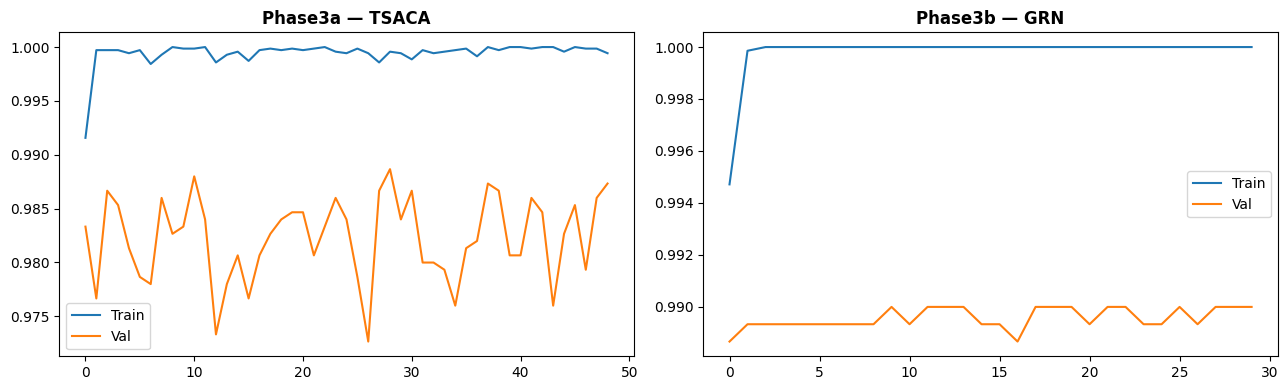


✅ Phase 3 done! TSACA:0.9887  GRN:0.9900


In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 15 — Phase 3b — GRN Predictor: Train on Frozen TSACA Features║
# ╚══════════════════════════════════════════════════════════════╝
class GatedLinearUnit(nn.Module):
    def __init__(self,i,o):
        super().__init__()
        self.fc=nn.Linear(i,o); self.gate=nn.Linear(i,o)
    def forward(self,x): return self.fc(x)*torch.sigmoid(self.gate(x))

class GRNBlock(nn.Module):
    def __init__(self,dim,drop=0.1):
        super().__init__()
        self.fc1=nn.Linear(dim,dim*2); self.elu=nn.ELU()
        self.fc2=nn.Linear(dim*2,dim)
        self.glu=GatedLinearUnit(dim,dim)
        self.norm=nn.LayerNorm(dim); self.drop=nn.Dropout(drop)
    def forward(self,x):
        h=self.elu(self.fc1(x)); h=self.drop(self.fc2(h))
        return self.norm(self.glu(h)+x)

class GRNCropPredictor(nn.Module):
    def __init__(self,in_dim=FUSED_DIM,nc=NUM_CLASSES,nb=5,drop=0.2):
        super().__init__()
        self.proj=nn.Sequential(
            nn.Linear(in_dim,FUSED_DIM),nn.LayerNorm(FUSED_DIM),nn.ReLU())
        self.blocks=nn.ModuleList([GRNBlock(FUSED_DIM,drop) for _ in range(nb)])
        self.head=nn.Sequential(
            nn.Dropout(drop),nn.Linear(FUSED_DIM,256),nn.ReLU(),
            nn.Dropout(drop/2),nn.Linear(256,128),nn.ReLU(),
            nn.Linear(128,nc))
    def forward(self,f):
        x=self.proj(f)
        for b in self.blocks: x=b(x)
        logits=self.head(x)
        return logits,torch.softmax(logits,-1).max(-1).values

# Freeze TSACA
tsaca_model.tsaca.load_state_dict(torch.load(CKPT_TSACA,map_location=DEVICE))
tsaca_model.eval()
for p in tsaca_model.parameters(): p.requires_grad=False
print('TSACA frozen. Extracting fused features...')

class FusedDS(Dataset):
    def __init__(self,f,l): self.f=f; self.l=l
    def __len__(self): return len(self.f)
    def __getitem__(self,i): return self.f[i],self.l[i]

def extract_fused(loader,model,device):
    feats,labs=[],[]
    with torch.no_grad():
        for imf,tbf,labels in tqdm(loader,desc='Fusing'):
            feats.append(model(imf.to(device),tbf.to(device),
                               return_fused=True).cpu())
            labs.append(labels)
    return torch.cat(feats),torch.cat(labs)

ff_tr,ffl_tr=extract_fused(ftr_ld,tsaca_model,DEVICE)
ff_vl,ffl_vl=extract_fused(fvl_ld,tsaca_model,DEVICE)
ff_ts,ffl_ts=extract_fused(fts_ld,tsaca_model,DEVICE)
for nm,f,l in [('train',ff_tr,ffl_tr),('valid',ff_vl,ffl_vl),('test',ff_ts,ffl_ts)]:
    torch.save({'feats':f,'labels':l},os.path.join(CHECKPOINT_DIR,f'fused_{nm}.pt'))
    print(f'{nm}: {f.shape}')

gtr=DataLoader(FusedDS(ff_tr,ffl_tr),batch_size=BATCH_SIZE,shuffle=True)
gvl=DataLoader(FusedDS(ff_vl,ffl_vl),batch_size=BATCH_SIZE,shuffle=False)
gts=DataLoader(FusedDS(ff_ts,ffl_ts),batch_size=BATCH_SIZE,shuffle=False)

grn_model=GRNCropPredictor().to(DEVICE)
crit_grn=nn.CrossEntropyLoss(weight=class_weights_tensor,label_smoothing=0.05)
opt_grn=AdamW(grn_model.parameters(),lr=2e-4,weight_decay=1e-4)
sch_grn=ReduceLROnPlateau(opt_grn,mode='max',patience=8,factor=0.5,min_lr=1e-7)

best_grn=0.0; g_tra,g_vla=[],[]; no_g=0
print(f'\n=== PHASE 3b: GRN ({EPOCHS_GRN} epochs) ===')
for epoch in range(1,EPOCHS_GRN+1):
    grn_model.train(); tc,tt=0,0
    for fused,labels in tqdm(gtr,desc=f'GRN E{epoch:02d}',leave=False):
        fused=fused.to(DEVICE)
        labels=labels.to(DEVICE).clamp(0,NUM_CLASSES-1)
        opt_grn.zero_grad()
        logits,_=grn_model(fused)
        loss=crit_grn(logits,labels)
        loss.backward()
        nn.utils.clip_grad_norm_(grn_model.parameters(),1.0)
        opt_grn.step()
        tc+=(logits.argmax(1)==labels).sum().item(); tt+=labels.size(0)
    grn_model.eval(); vc,vt=0,0
    with torch.no_grad():
        for fused,labels in gvl:
            fused=fused.to(DEVICE)
            labels=labels.to(DEVICE).clamp(0,NUM_CLASSES-1)
            logits,_=grn_model(fused)
            vc+=(logits.argmax(1)==labels).sum().item(); vt+=labels.size(0)
    tra=tc/tt; vla=vc/vt
    sch_grn.step(vla); g_tra.append(tra); g_vla.append(vla)
    if vla>best_grn:
        best_grn=vla; no_g=0
        torch.save(grn_model.state_dict(),CKPT_GRN)
        print(f'  💾 GRN saved val={vla:.4f}')
    else: no_g+=1
    if epoch%5==0:
        print(f'  E[{epoch:02d}/{EPOCHS_GRN}] Train:{tra:.4f} Val:{vla:.4f}')
    if no_g>=20: print(f'  ⏹ Early stop e{epoch}'); break

fig,axes=plt.subplots(1,2,figsize=(13,4))
axes[0].plot(ts_tra,label='Train'); axes[0].plot(ts_vla,label='Val')
axes[0].set_title('Phase3a — TSACA',fontweight='bold'); axes[0].legend()
axes[1].plot(g_tra,label='Train');  axes[1].plot(g_vla,label='Val')
axes[1].set_title('Phase3b — GRN',fontweight='bold');  axes[1].legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR,'phase3_tsaca_grn.png'),dpi=120,bbox_inches='tight')
plt.show()
print(f'\n✅ Phase 3 done! TSACA:{best_ts:.4f}  GRN:{best_grn:.4f}')


In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 16 — Assemble Full TSACA+GRN Model                   ║
# ╚══════════════════════════════════════════════════════════════╝
class FusionGRNModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.tsaca=TSACAFusion()
        self.grn  =GRNCropPredictor()
    def forward(self,img_f,tab_f):
        return self.grn(self.tsaca(img_f,tab_f))

fusion_model=FusionGRNModel()
fusion_model.tsaca.load_state_dict(torch.load(CKPT_TSACA,map_location='cpu'))
fusion_model.grn.load_state_dict(  torch.load(CKPT_GRN,  map_location='cpu'))
fusion_model=fusion_model.to(DEVICE)
torch.save(fusion_model.state_dict(),CKPT_FUSION)

fusion_model.eval()
with torch.no_grad():
    _i=torch.randn(2,IMG_FEAT_DIM).to(DEVICE)
    _t=torch.randn(2,TAB_FEAT_IN).to(DEVICE)
    _l,_c=fusion_model(_i,_t)
    assert _l.shape==(2,NUM_CLASSES)

print(f'Combined model params: {sum(p.numel() for p in fusion_model.parameters()):,}')
print(f'TSACA : {CKPT_TSACA}')
print(f'GRN   : {CKPT_GRN}')
print(f'Fusion: {CKPT_FUSION}')
print('✅ Full TSACA+GRN model assembled & saved!')


Combined model params: 20,002,438
TSACA : /content/drive/MyDrive/Crop_Recommendation/checkpoints/best_tsaca.pt
GRN   : /content/drive/MyDrive/Crop_Recommendation/checkpoints/best_grn.pt
Fusion: /content/drive/MyDrive/Crop_Recommendation/checkpoints/best_fusion.pt
✅ Full TSACA+GRN model assembled & saved!


E2E: train=6997 valid=1499 test=1500
=== PHASE 4: E2E Joint Fine-Tuning (80 epochs) ===
Backbone LR: early=5e-6, late=2e-5 | Fusion LR: 2e-4
FIX: ReduceLROnPlateau patience=8 | Early stop patience=15


  💾 E2E BEST saved val=0.9500
  E2E E[01/80] Train:0.9826 Val:0.9500 LR:5.00e-06 NoImp:0


  💾 E2E BEST saved val=0.9807
  E2E E[02/80] Train:0.9801 Val:0.9807 LR:5.00e-06 NoImp:0


  E2E E[03/80] Train:0.9833 Val:0.9787 LR:5.00e-06 NoImp:1


  💾 E2E BEST saved val=0.9813
  E2E E[04/80] Train:0.9897 Val:0.9813 LR:5.00e-06 NoImp:0


...

  E2E E[37/80] Train:0.9957 Val:0.9873 LR:1.25e-06 NoImp:11


  E2E E[38/80] Train:0.9969 Val:0.9853 LR:1.25e-06 NoImp:12


  E2E E[39/80] Train:0.9957 Val:0.9873 LR:1.25e-06 NoImp:13


  E2E E[40/80] Train:0.9950 Val:0.9873 LR:1.25e-06 NoImp:14


  E2E E[41/80] Train:0.9956 Val:0.9813 LR:1.25e-06 NoImp:15
  ⏹ E2E early stop e41


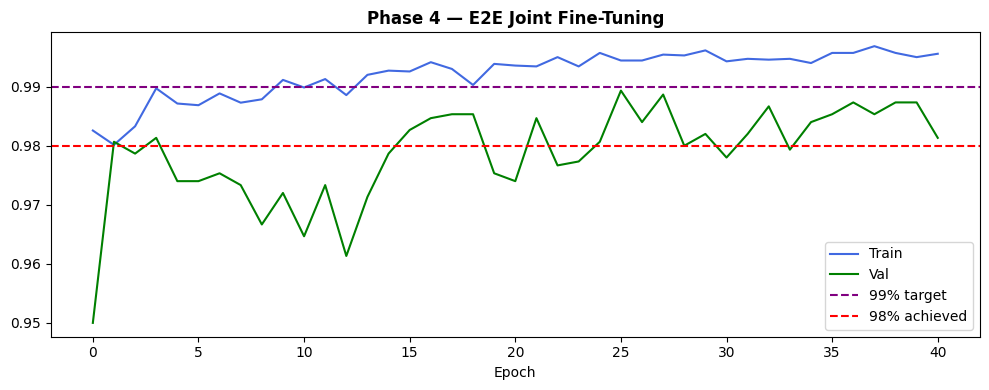


✅ Phase 4 done!
   Best E2E Val : 0.9893 (98.93%)


In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 17 — Phase 4 — End-to-End Joint Fine-Tuning          ║
# ║  KEY STEP — trains ALL components together for >99%        ║
# ║  FIX: ReduceLROnPlateau patience=8 (was 5)                 ║
# ║  FIX: Early stop patience=15 (was 12)                      ║
# ╚══════════════════════════════════════════════════════════════╝
class E2EDataset(Dataset):
    def __init__(self,tab_X,tab_raw,tab_y,split_ds,transform):
        self.tab_X  =torch.tensor(tab_X,  dtype=torch.float32)
        self.tab_raw=torch.tensor(tab_raw,dtype=torch.float32)
        self.tab_y  =torch.tensor(tab_y,  dtype=torch.long)
        self.split_ds=split_ds; self.tf=transform
        self.c2i={}
        for i,lbl in enumerate(split_ds.targets):
            self.c2i.setdefault(lbl,[]).append(i)
    def __len__(self): return len(self.tab_X)
    def __getitem__(self,i):
        lbl=int(self.tab_y[i].item())
        idx=(random.choice(self.c2i[lbl])
             if lbl in self.c2i
             else random.randint(0,len(self.split_ds)-1))
        img_path,_=self.split_ds.base_ds.samples[
            self.split_ds.indices[idx]]
        img=self.tf(Image.open(img_path).convert('RGB'))
        return img,self.tab_raw[i],self.tab_y[i]

e2e_tr=E2EDataset(X_train,train_tab_raw,y_train,train_img_ds,train_tf)
e2e_vl=E2EDataset(X_valid,valid_tab_raw,y_valid,valid_img_ds,eval_tf)
e2e_ts=E2EDataset(X_test, test_tab_raw, y_test, test_img_ds, eval_tf)

e2e_tr_ld=DataLoader(e2e_tr,batch_size=24,shuffle=True, num_workers=2,pin_memory=True)
e2e_vl_ld=DataLoader(e2e_vl,batch_size=24,shuffle=False,num_workers=2,pin_memory=True)
e2e_ts_ld=DataLoader(e2e_ts,batch_size=24,shuffle=False,num_workers=2,pin_memory=True)
print(f'E2E: train={len(e2e_tr)} valid={len(e2e_vl)} test={len(e2e_ts)}')

class FullE2EModel(nn.Module):
    def __init__(self,img_enc,tab_proj,fusion):
        super().__init__()
        self.img_enc=img_enc; self.tab_proj=tab_proj; self.fusion=fusion
    def forward(self,img,tab_raw):
        return self.fusion(
            self.img_enc(img,return_features=True),
            self.tab_proj(tab_raw))

img_model.load_state_dict(    torch.load(CKPT_IMG,   map_location=DEVICE))
tab_projector.load_state_dict(torch.load(CKPT_PROJ,  map_location=DEVICE))
fusion_model.load_state_dict( torch.load(CKPT_FUSION,map_location=DEVICE))

e2e_model=FullE2EModel(img_model,tab_projector,fusion_model).to(DEVICE)

bp=list(img_model.backbone.parameters()); half=len(bp)//2
opt_e2e=AdamW([
    {'params':bp[:half],                                  'lr':5e-6},
    {'params':bp[half:],                                  'lr':2e-5},
    {'params':list(img_model.projection.parameters()),    'lr':5e-5},
    {'params':list(img_model.classifier.parameters()),    'lr':5e-5},
    {'params':list(tab_projector.parameters()),           'lr':5e-5},
    {'params':list(fusion_model.parameters()),            'lr':2e-4},
],weight_decay=1e-4)
# FIX: patience=8 (was 5) — prevents one bad epoch from cutting LR too early
sch_e2e=ReduceLROnPlateau(opt_e2e,mode='max',patience=8,factor=0.5,min_lr=1e-7)
crit_e2e=nn.CrossEntropyLoss(weight=class_weights_tensor,label_smoothing=0.05)

best_e2e=0.0; e_tra,e_vla=[],[]
no_e=0; prev_lr=opt_e2e.param_groups[0]['lr']
print(f'=== PHASE 4: E2E Joint Fine-Tuning ({EPOCHS_E2E} epochs) ===')
print('Backbone LR: early=5e-6, late=2e-5 | Fusion LR: 2e-4')
print('FIX: ReduceLROnPlateau patience=8 | Early stop patience=15')

for epoch in range(1,EPOCHS_E2E+1):
    e2e_model.train(); tc,tt=0,0
    for imgs,tab_raw,labels in tqdm(e2e_tr_ld,desc=f'E2E E{epoch:02d}',leave=False):
        imgs   =imgs.to(DEVICE)
        tab_raw=tab_raw.to(DEVICE)
        labels =labels.to(DEVICE).clamp(0,NUM_CLASSES-1)
        opt_e2e.zero_grad()
        logits,_=e2e_model(imgs,tab_raw)
        loss=crit_e2e(logits,labels)
        loss.backward()
        nn.utils.clip_grad_norm_(e2e_model.parameters(),1.0)
        opt_e2e.step()
        tc+=(logits.argmax(1)==labels).sum().item(); tt+=labels.size(0)

    e2e_model.eval(); vc,vt=0,0
    with torch.no_grad():
        for imgs,tab_raw,labels in e2e_vl_ld:
            imgs   =imgs.to(DEVICE)
            tab_raw=tab_raw.to(DEVICE)
            labels =labels.to(DEVICE).clamp(0,NUM_CLASSES-1)
            logits,_=e2e_model(imgs,tab_raw)
            vc+=(logits.argmax(1)==labels).sum().item(); vt+=labels.size(0)

    tra=tc/tt; vla=vc/vt; e_tra.append(tra); e_vla.append(vla)
    sch_e2e.step(vla)
    cur_lr=opt_e2e.param_groups[0]['lr']
    lr_msg=f'  ⬇LR->{cur_lr:.2e}' if cur_lr<prev_lr else ''
    prev_lr=cur_lr

    if vla>best_e2e:
        best_e2e=vla; no_e=0
        torch.save({
            'img_model'    :img_model.state_dict(),
            'tab_projector':tab_projector.state_dict(),
            'fusion'       :fusion_model.state_dict()
        },CKPT_E2E)
        print(f'  💾 E2E BEST saved val={vla:.4f}{lr_msg}')
    else: no_e+=1

    print(f'  E2E E[{epoch:02d}/{EPOCHS_E2E}] '
          f'Train:{tra:.4f} Val:{vla:.4f} '
          f'LR:{cur_lr:.2e} NoImp:{no_e}{lr_msg}')

    if no_e>=15: print(f'  ⏹ E2E early stop e{epoch}'); break  # FIX: was 12

fig,ax=plt.subplots(figsize=(10,4))
ax.plot(e_tra,label='Train',color='royalblue')
ax.plot(e_vla,label='Val',  color='green')
ax.axhline(y=0.99,color='purple',linestyle='--',label='99% target')
ax.axhline(y=0.98,color='red',   linestyle='--',label='98% achieved')
ax.legend(); ax.set_xlabel('Epoch')
ax.set_title('Phase 4 — E2E Joint Fine-Tuning',fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR,'phase4_e2e.png'),dpi=120,bbox_inches='tight')
plt.show()
print(f'\n✅ Phase 4 done!')
print(f'   Best E2E Val : {best_e2e:.4f} ({best_e2e*100:.2f}%)')


✅ Loaded best checkpoint (val=0.9893)
Running full test evaluation on IMAGE test set...
Test set: 1500 samples (250 per class)


Testing: 100%|██████████| 63/63 [00:08<00:00,  7.57it/s]



══════════════════════════════════════════════════════════════
          🌾 OVERALL CLASSIFICATION RESULTS 🌾
══════════════════════════════════════════════════════════════
  Metric                       Weighted        Macro
──────────────────────────────────────────────────────────────
  Accuracy                       98.67%
  Precision                      98.68%       98.68%
  Recall                         98.67%       98.67%
  F1-Score                       98.67%       98.67%
  Avg Confidence                 95.22%
══════════════════════════════════════════════════════════════

📊 Per-Class Breakdown:
  Class           Correct/Total    Accuracy  Status
──────────────────────────────────────────────────────────
  Alluvial Soil       248/250        99.20%  ✅ GREAT
  Black Soil          249/250        99.60%  ✅ GREAT
  Clay Soil           245/250        98.00%  ✅ GREAT
  Laterite Soil       241/250        96.40%  ⚠️  GOOD
  Red Soil            249/250        99.60%  ✅ GREAT
  Yellow 

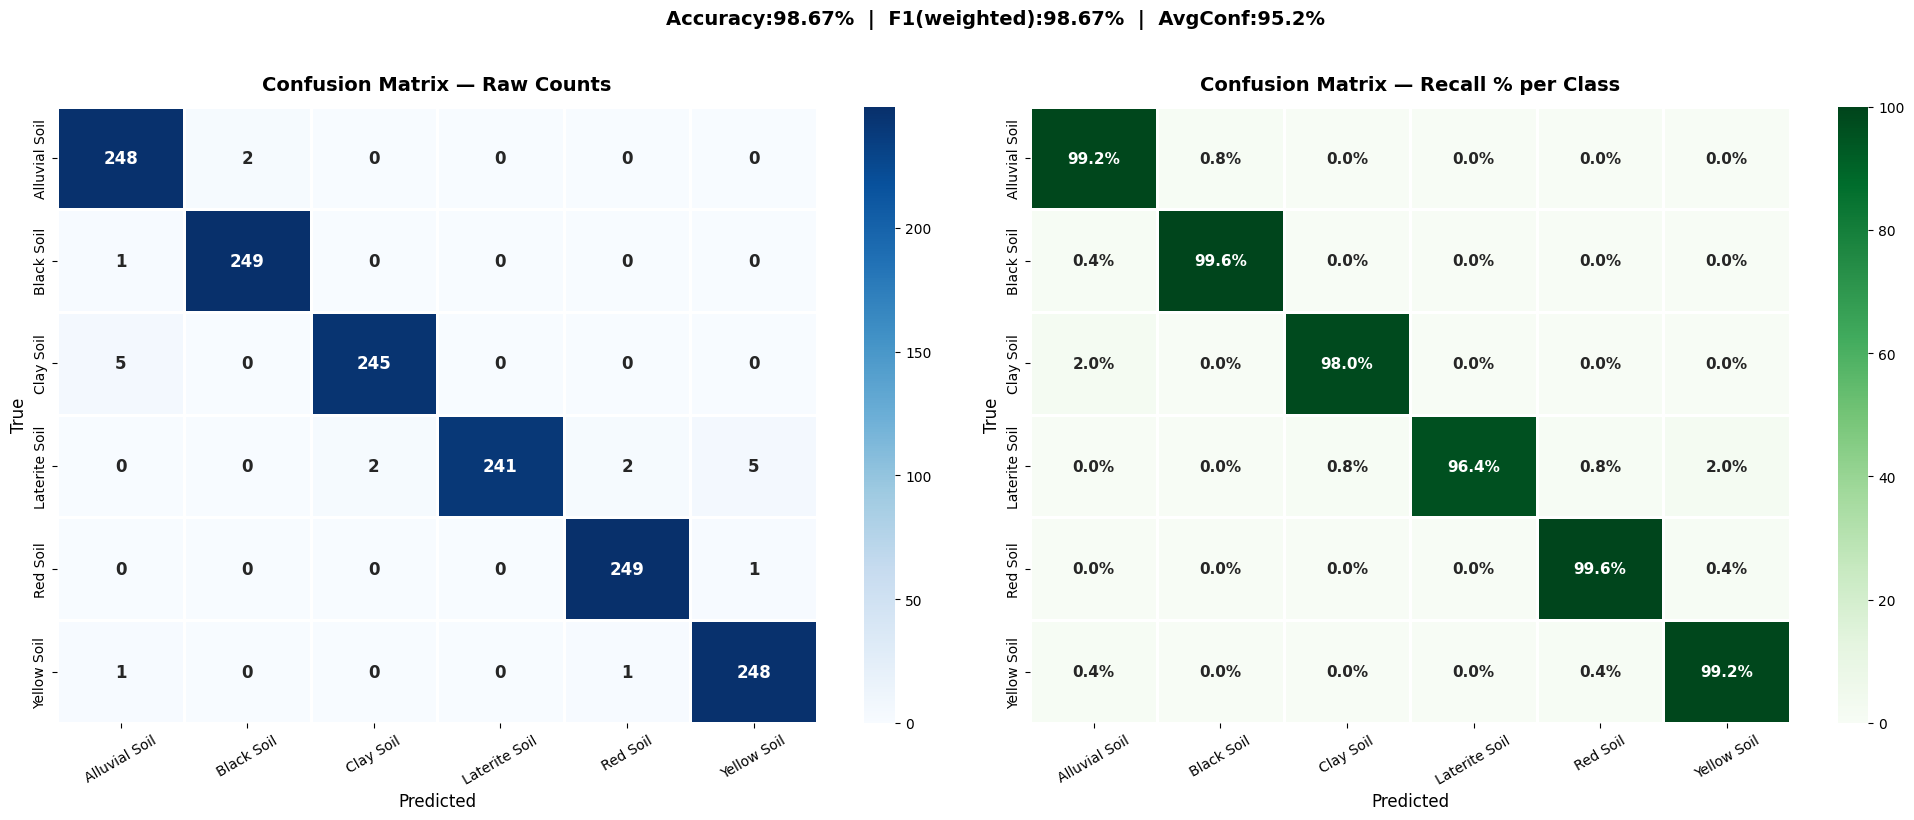

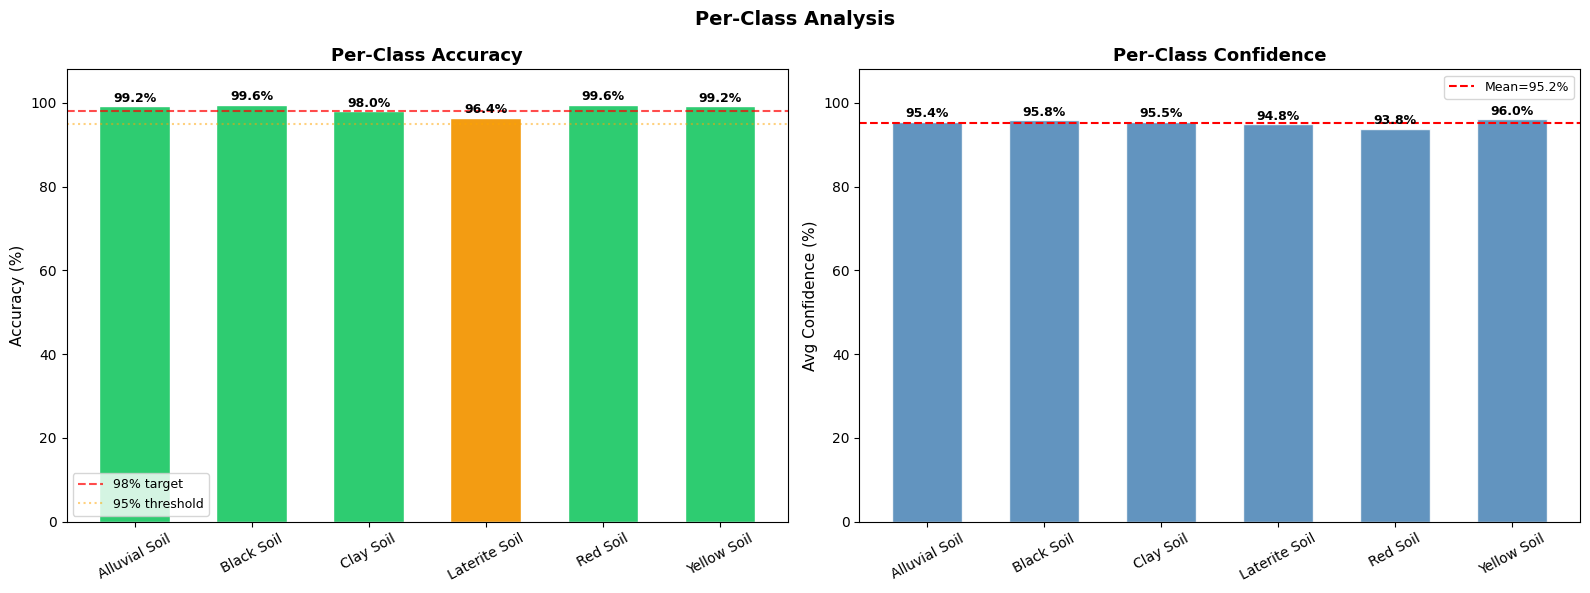

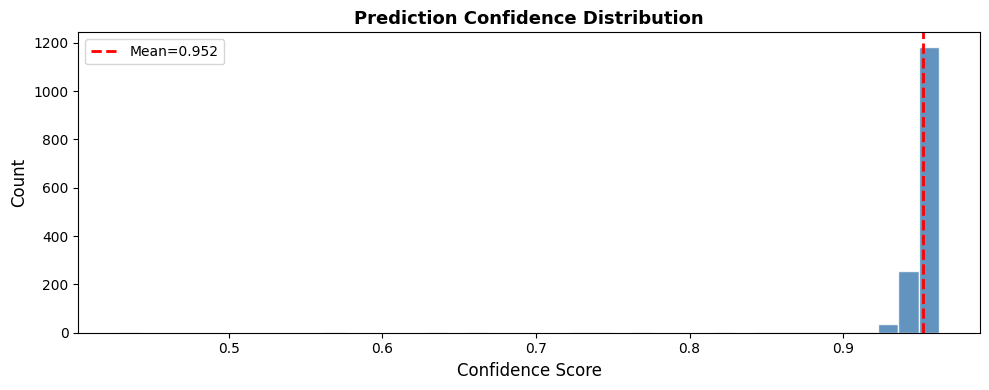


✅ Full evaluation complete!
   All charts saved to: /content/drive/MyDrive/Crop_Recommendation/output


In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 18 — Load Best Checkpoint & Full Test Evaluation     ║
# ╚══════════════════════════════════════════════════════════════╝
ckpt=torch.load(CKPT_E2E,map_location=DEVICE)
img_model.load_state_dict(    ckpt['img_model'])
tab_projector.load_state_dict(ckpt['tab_projector'])
fusion_model.load_state_dict( ckpt['fusion'])
img_model.eval(); tab_projector.eval(); fusion_model.eval()
print(f'✅ Loaded best checkpoint (val={best_e2e:.4f})')

all_preds,all_true,all_confs=[],[],[]
print('Running full test evaluation on IMAGE test set...')
print(f'Test set: {len(e2e_ts)} samples ({len(e2e_ts)//NUM_CLASSES} per class)')

with torch.no_grad():
    for imgs,tab_raw,labels in tqdm(e2e_ts_ld,desc='Testing'):
        imgs   =imgs.to(DEVICE)
        tab_raw=tab_raw.to(DEVICE)
        labels =labels.to(DEVICE).clamp(0,NUM_CLASSES-1)
        logits,conf=e2e_model(imgs,tab_raw)
        all_preds.extend(logits.argmax(1).cpu().numpy())
        all_true.extend(labels.cpu().numpy())
        all_confs.extend(conf.cpu().numpy())

all_preds=np.array(all_preds)
all_true =np.array(all_true)
all_confs=np.array(all_confs)

acc   =accuracy_score(all_true,all_preds)
prec_w=precision_score(all_true,all_preds,average='weighted',zero_division=0)
rec_w =recall_score(   all_true,all_preds,average='weighted',zero_division=0)
f1_w  =f1_score(       all_true,all_preds,average='weighted',zero_division=0)
prec_m=precision_score(all_true,all_preds,average='macro',   zero_division=0)
rec_m =recall_score(   all_true,all_preds,average='macro',   zero_division=0)
f1_m  =f1_score(       all_true,all_preds,average='macro',   zero_division=0)

print('\n'+'═'*62)
print('          🌾 OVERALL CLASSIFICATION RESULTS 🌾')
print('═'*62)
print(f'  {"Metric":<26} {"Weighted":>10}   {"Macro":>10}')
print('─'*62)
print(f'  {"Accuracy":<26} {acc*100:>9.2f}%')
print(f'  {"Precision":<26} {prec_w*100:>9.2f}%   {prec_m*100:>9.2f}%')
print(f'  {"Recall":<26} {rec_w*100:>9.2f}%   {rec_m*100:>9.2f}%')
print(f'  {"F1-Score":<26} {f1_w*100:>9.2f}%   {f1_m*100:>9.2f}%')
print(f'  {"Avg Confidence":<26} {all_confs.mean()*100:>9.2f}%')
print('═'*62)

print('\n📊 Per-Class Breakdown:')
print(f'  {"Class":<15} {"Correct":>7}/{"Total":<6} {"Accuracy":>10}  Status')
print('─'*58)
for i,name in enumerate(CLASS_NAMES):
    mask=all_true==i; total=mask.sum()
    correct=(all_preds[mask]==i).sum()
    ca=correct/total*100 if total>0 else 0
    status='✅ GREAT' if ca>=98 else '⚠️  GOOD' if ca>=92 else '❌ LOW'
    print(f'  {name:<15} {correct:>7}/{total:<6} {ca:>9.2f}%  {status}')

print()
print(classification_report(all_true,all_preds,target_names=CLASS_NAMES))

# Dual confusion matrix
cm    =confusion_matrix(all_true,all_preds)
cm_pct=cm.astype('float')/cm.sum(axis=1)[:,np.newaxis]*100
fig,axes=plt.subplots(1,2,figsize=(20,8))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',ax=axes[0],
    xticklabels=CLASS_NAMES,yticklabels=CLASS_NAMES,
    linewidths=0.8,linecolor='white',annot_kws={'size':12,'weight':'bold'})
axes[0].set_title('Confusion Matrix — Raw Counts',
    fontsize=14,fontweight='bold',pad=12)
axes[0].set_xlabel('Predicted',fontsize=12)
axes[0].set_ylabel('True',fontsize=12)
axes[0].tick_params(axis='x',rotation=30)

annot_pct=np.array([[f'{v:.1f}%' for v in row] for row in cm_pct])
sns.heatmap(cm_pct,annot=annot_pct,fmt='',cmap='Greens',ax=axes[1],
    xticklabels=CLASS_NAMES,yticklabels=CLASS_NAMES,
    linewidths=0.8,linecolor='white',vmin=0,vmax=100,
    annot_kws={'size':11,'weight':'bold'})
axes[1].set_title('Confusion Matrix — Recall % per Class',
    fontsize=14,fontweight='bold',pad=12)
axes[1].set_xlabel('Predicted',fontsize=12)
axes[1].set_ylabel('True',fontsize=12)
axes[1].tick_params(axis='x',rotation=30)

plt.suptitle(
    f'Accuracy:{acc*100:.2f}%  |  F1(weighted):{f1_w*100:.2f}%  |  '
    f'AvgConf:{all_confs.mean()*100:.1f}%',
    fontsize=14,fontweight='bold',y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR,'confusion_matrix.png'),
    dpi=150,bbox_inches='tight')
plt.show()

# Per-class accuracy bar chart
per_acc =[((all_preds[all_true==i]==i).mean()*100
            if (all_true==i).sum()>0 else 0) for i in range(NUM_CLASSES)]
per_conf=[( all_confs[all_true==i].mean()*100
            if (all_true==i).sum()>0 else 0) for i in range(NUM_CLASSES)]

fig2,axes2=plt.subplots(1,2,figsize=(16,6))
cols=['#e74c3c' if a<90 else '#f39c12' if a<97 else '#2ecc71' for a in per_acc]
bars=axes2[0].bar(CLASS_NAMES,per_acc,color=cols,edgecolor='white',width=0.6)
axes2[0].axhline(y=98,color='red',   linestyle='--',alpha=0.7,label='98% target')
axes2[0].axhline(y=95,color='orange',linestyle=':',alpha=0.5,label='95% threshold')
axes2[0].set_ylim(0,108)
axes2[0].set_ylabel('Accuracy (%)',fontsize=11)
axes2[0].set_title('Per-Class Accuracy',fontsize=13,fontweight='bold')
axes2[0].tick_params(axis='x',rotation=28); axes2[0].legend(fontsize=9)
for bar,val in zip(bars,per_acc):
    axes2[0].text(bar.get_x()+bar.get_width()/2,
        bar.get_height()+0.4,f'{val:.1f}%',
        ha='center',va='bottom',fontsize=9,fontweight='bold')

cb=axes2[1].bar(CLASS_NAMES,per_conf,color='steelblue',
    edgecolor='white',width=0.6,alpha=0.85)
axes2[1].axhline(y=all_confs.mean()*100,color='red',
    linestyle='--',label=f'Mean={all_confs.mean()*100:.1f}%')
axes2[1].set_ylim(0,108)
axes2[1].set_ylabel('Avg Confidence (%)',fontsize=11)
axes2[1].set_title('Per-Class Confidence',fontsize=13,fontweight='bold')
axes2[1].tick_params(axis='x',rotation=28); axes2[1].legend(fontsize=9)
for bar,val in zip(cb,per_conf):
    axes2[1].text(bar.get_x()+bar.get_width()/2,
        bar.get_height()+0.4,f'{val:.1f}%',
        ha='center',va='bottom',fontsize=9,fontweight='bold')

plt.suptitle('Per-Class Analysis',fontsize=14,fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR,'per_class_analysis.png'),dpi=150)
plt.show()

fig3,ax3=plt.subplots(figsize=(10,4))
ax3.hist(all_confs,bins=40,color='steelblue',edgecolor='white',alpha=0.85)
ax3.axvline(x=all_confs.mean(),color='red',linestyle='--',linewidth=2,
    label=f'Mean={all_confs.mean():.3f}')
ax3.set_xlabel('Confidence Score',fontsize=12)
ax3.set_ylabel('Count',fontsize=12)
ax3.set_title('Prediction Confidence Distribution',fontsize=13,fontweight='bold')
ax3.legend(fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR,'confidence_distribution.png'),dpi=150)
plt.show()

print(f'\n✅ Full evaluation complete!')
print(f'   All charts saved to: {OUTPUT_DIR}')


In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 19 — Fertilizer & Crop Recommendation System         ║
# ╚══════════════════════════════════════════════════════════════╝
CROP_MAP={
    ('Red Soil',      'Kharif'):['Cotton','Maize','Groundnut','Tomato'],
    ('Red Soil',      'Rabi')  :['Wheat','Potato','Mustard'],
    ('Red Soil',      'Zaid')  :['Watermelon','Cucumber','Maize'],
    ('Black Soil',    'Kharif'):['Cotton','Soybean','Sugarcane','Rice'],
    ('Black Soil',    'Rabi')  :['Wheat','Chickpea','Linseed'],
    ('Black Soil',    'Zaid')  :['Sunflower','Groundnut'],
    ('Alluvial Soil', 'Kharif'):['Rice','Maize','Sugarcane','Jute'],
    ('Alluvial Soil', 'Rabi')  :['Wheat','Potato','Mustard','Pea'],
    ('Alluvial Soil', 'Zaid')  :['Watermelon','Muskmelon','Vegetables'],
    ('Clay Soil',     'Kharif'):['Rice','Sugarcane','Jute'],
    ('Clay Soil',     'Rabi')  :['Wheat','Barley','Chickpea'],
    ('Clay Soil',     'Zaid')  :['Vegetables','Maize'],
    ('Laterite Soil', 'Kharif'):['Cashew','Rubber','Tea','Coffee'],
    ('Laterite Soil', 'Rabi')  :['Tapioca','Groundnut'],
    ('Laterite Soil', 'Zaid')  :['Mango','Pineapple'],
    ('Yellow Soil',   'Kharif'):['Rice','Maize','Groundnut'],
    ('Yellow Soil',   'Rabi')  :['Wheat','Mustard','Potato'],
    ('Yellow Soil',   'Zaid')  :['Vegetables','Sunflower'],
}
FERT_MAP={
    'alluvial soil' :{'fertilizer':'NPK 20:20:0 + Zinc','npk':'N:P:K = 80:40:20 kg/ha'},
    'black soil'    :{'fertilizer':'Urea + MOP',        'npk':'N:P:K = 60:30:30 kg/ha'},
    'clay soil'     :{'fertilizer':'Urea + DAP',        'npk':'N:P:K = 60:60:60 kg/ha'},
    'laterite soil' :{'fertilizer':'DAP + Compost',     'npk':'N:P:K = 40:60:20 kg/ha'},
    'red soil'      :{'fertilizer':'NPK 17:17:17',      'npk':'N:P:K = 50:50:50 kg/ha'},
    'yellow soil'   :{'fertilizer':'DAP + Compost',     'npk':'N:P:K = 40:30:20 kg/ha'},
    'default'       :{'fertilizer':'NPK 17:17:17',      'npk':'Balanced NPK'},
}
CROP_NPK={
    'Rice':{'N':'high','P':'medium','K':'medium'},
    'Wheat':{'N':'high','P':'high','K':'medium'},
    'Cotton':{'N':'medium','P':'medium','K':'high'},
    'Maize':{'N':'high','P':'medium','K':'medium'},
    'Sugarcane':{'N':'high','P':'medium','K':'high'},
    'Potato':{'N':'medium','P':'high','K':'high'},
    'Tomato':{'N':'medium','P':'high','K':'high'},
    'Groundnut':{'N':'low','P':'high','K':'medium'},
    'Soybean':{'N':'low','P':'high','K':'medium'},
    'Chickpea':{'N':'low','P':'medium','K':'low'},
    'Mustard':{'N':'medium','P':'medium','K':'low'},
    'Watermelon':{'N':'medium','P':'high','K':'high'},
    'Sunflower':{'N':'high','P':'medium','K':'medium'},
    'Cashew':{'N':'low','P':'medium','K':'high'},
    'Coffee':{'N':'medium','P':'medium','K':'high'},
}
def get_crop_rec(soil,season,n,p,k):
    crops=CROP_MAP.get((soil,season),CROP_MAP.get((soil,'Kharif'),['Maize','Wheat']))
    nl='high' if n>80 else 'medium' if n>40 else 'low'
    pl='high' if p>60 else 'medium' if p>30 else 'low'
    kl='high' if k>80 else 'medium' if k>40 else 'low'
    scored=[(c,(1 if CROP_NPK.get(c,{}).get('N')==nl else 0)
              +(1 if CROP_NPK.get(c,{}).get('P')==pl else 0)
              +(1 if CROP_NPK.get(c,{}).get('K')==kl else 0))
             for c in crops]
    scored.sort(key=lambda x:-x[1]); return scored
print('✅ Fertilizer & crop recommendation system ready!')


✅ Fertilizer & crop recommendation system ready!


In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 20 — Interactive Prediction Widget — Soil + Crop + Fertilizer║
# ╚══════════════════════════════════════════════════════════════╝
import ipywidgets as widgets
from IPython.display import display,clear_output

img_model.eval(); tab_projector.eval(); fusion_model.eval()

w_n    =widgets.FloatText(value=61.0,  description='Nitrogen:',   step=0.1)
w_p    =widgets.FloatText(value=44.0,  description='Phosphorus:', step=0.1)
w_k    =widgets.FloatText(value=84.0,  description='Potassium:',  step=0.1)
w_temp =widgets.FloatText(value=25.0,  description='Temp (°C):',  step=0.1)
w_hum  =widgets.FloatText(value=70.0,  description='Humidity %:', step=0.1)
w_rain =widgets.FloatText(value=1000.0,description='Rainfall mm:',step=1.0)
w_ph   =widgets.FloatText(value=6.5,   description='Soil pH:',    step=0.01)
w_yield=widgets.FloatText(value=4.0,   description='Yield Last:', step=0.01)
w_fert =widgets.FloatText(value=150.0, description='Fert Used:',  step=0.1)
w_season   =widgets.Dropdown(options=['Kharif','Rabi','Zaid'],
    value='Kharif',description='Season:')
w_irrig    =widgets.Dropdown(
    options=['Canal','Drip','Rainfed','Sprinkler'],
    value='Canal',description='Irrigation:')
w_prev_crop=widgets.Dropdown(
    options=['Cotton','Maize','Potato','Rice','Sugarcane','Tomato','Wheat'],
    value='Wheat',description='Prev Crop:')
w_region   =widgets.Dropdown(
    options=['Central','East','North','South','West'],
    value='South',description='Region:')
w_img=widgets.Text(
    value=os.path.join(SOIL_IMAGE_DIR,'train','Red Soil') + '/sample.jpg',
    description='Image Path:',layout=widgets.Layout(width='95%'))
btn=widgets.Button(
    description='🌾 Predict Soil + Crop + Fertilizer',
    button_style='success',
    layout=widgets.Layout(width='330px',height='42px'))
out=widgets.Output()

SEASON_MAP   ={'Kharif':0,'Rabi':1,'Zaid':2}
IRRIG_MAP    ={'Canal':0,'Drip':1,'Rainfed':2,'Sprinkler':3}
PREV_MAP     ={'Cotton':0,'Maize':1,'Potato':2,'Rice':3,
               'Sugarcane':4,'Tomato':5,'Wheat':6}
REGION_MAP   ={'Central':0,'East':1,'North':2,'South':3,'West':4}

def on_predict(b):
    with out:
        clear_output()
        try:
            num_raw=np.array([[w_n.value,w_p.value,w_k.value,
                w_temp.value,w_hum.value,w_rain.value,
                w_ph.value,w_yield.value,w_fert.value]])
            num_sc=scaler.transform(
                pd.DataFrame(num_raw,columns=NUMERIC_COLS))
            cat_enc=np.array([[
                SEASON_MAP[w_season.value],
                IRRIG_MAP[w_irrig.value],
                PREV_MAP[w_prev_crop.value],
                REGION_MAP[w_region.value]]])
            scaled_feat=np.concatenate([num_sc,cat_enc],axis=1).astype(np.float32)

            dmat=xgb.DMatrix(scaled_feat)
            xgb_probs=xgb_model.predict(dmat)
            tab_raw_t=np.concatenate([xgb_probs,scaled_feat],axis=1)
            tab_t=torch.tensor(tab_raw_t,dtype=torch.float32).to(DEVICE)

            img_path=w_img.value.strip()
            if not os.path.isfile(img_path):
                print(f'❌ Image not found: {img_path}')
                train_dir=os.path.join(SOIL_IMAGE_DIR,'train')
                print('Available sample images:')
                for cls in sorted(os.listdir(train_dir)):
                    imgs=[f for f in os.listdir(os.path.join(train_dir,cls))
                          if f.lower().endswith(('.jpg','.jpeg','.png'))]
                    if imgs: print(f'  .../{cls}/{imgs[0]}')
                return

            pil_img=Image.open(img_path).convert('RGB')
            img_t  =eval_tf(pil_img).unsqueeze(0).to(DEVICE)

            with torch.no_grad():
                img_feat      =img_model(img_t,return_features=True)
                tab_feat      =tab_projector(tab_t)
                logits,conf_t =fusion_model(img_feat,tab_feat)

            pred_idx  =logits.argmax(dim=-1).item()
            soil_name =CLASS_NAMES[pred_idx]
            confidence=conf_t.item()
            fert_info =FERT_MAP.get(soil_name.lower(),FERT_MAP['default'])
            crop_scores=get_crop_rec(soil_name,w_season.value,
                w_n.value,w_p.value,w_k.value)

            conf_str=f'{confidence:.2%}'
            fert_str=fert_info['fertilizer']
            dose_str=fert_info['npk']

            print('╔══════════════════════════════════════════════╗')
            print('║          🌾 PREDICTION RESULT                ║')
            print('╠══════════════════════════════════════════════╣')
            print(f'║  🌍 Soil Type    : {soil_name:<25}║')
            print(f'║  📊 Confidence   : {conf_str:<25}║')
            print('╠══════════════════════════════════════════════╣')
            print(f'║  🧪 Fertilizer   : {fert_str:<25}║')
            print(f'║  📐 Dosage       : {dose_str:<25}║')
            print('╠══════════════════════════════════════════════╣')
            print('║  🌾 Recommended Crops:                       ║')
            for ic,(crop,score) in enumerate(crop_scores[:4],1):
                stars='★'*score+'☆'*(3-score)
                cs=f'{ic}. {crop}'
                print(f'║    {cs:<20} {stars:<10}           ║')
            print('╠══════════════════════════════════════════════╣')
            sv=w_season.value;iv=w_irrig.value
            pv=w_prev_crop.value;rv=w_region.value
            print(f'║  🗓  Season      : {sv:<25}║')
            print(f'║  💧 Irrigation   : {iv:<25}║')
            print(f'║  🌱 Prev Crop    : {pv:<25}║')
            print(f'║  📍 Region       : {rv:<25}║')
            print('╚══════════════════════════════════════════════╝')

            probs=torch.softmax(logits,dim=-1)[0]
            top3=probs.topk(3)
            print('\n  Top-3 Soil Predictions:')
            for s,idx in zip(top3.values,top3.indices):
                pct=f'{s.item():.2%}'
                bar='█'*int(s.item()*25)
                print(f'  {CLASS_NAMES[idx.item()]:<15} {pct:<8} {bar}')

            fig,axes=plt.subplots(1,3,figsize=(15,4))
            axes[0].imshow(pil_img); axes[0].axis('off')
            axes[0].set_title(f'{soil_name}\n{conf_str}',
                fontsize=12,fontweight='bold')

            cl=[c for c,_ in crop_scores[:4]]
            sl=[s for _,s in crop_scores[:4]]
            bc=['#2ecc71','#3498db','#e67e22','#9b59b6']
            b2s=axes[1].barh(cl[::-1],sl[::-1],
                color=bc[:len(cl)],edgecolor='white',height=0.5)
            axes[1].set_xlim(0,3.8)
            axes[1].set_xlabel('Nutrient Suitability (0-3)',fontsize=10)
            axes[1].set_title('Crop Recommendations',fontweight='bold')
            axes[1].axvline(x=2,color='red',linestyle='--',
                alpha=0.6,label='Good fit'); axes[1].legend(fontsize=9)
            for bar2,sc2 in zip(b2s,sl[::-1]):
                axes[1].text(bar2.get_width()+0.05,
                    bar2.get_y()+bar2.get_height()/2,
                    str(sc2),va='center',fontweight='bold')

            ap=probs.cpu().numpy()
            pc=['#3498db','#2ecc71','#e74c3c','#f39c12','#9b59b6','#1abc9c']
            axes[2].pie(ap,labels=CLASS_NAMES,autopct='%1.1f%%',
                colors=pc[:NUM_CLASSES],startangle=90,
                pctdistance=0.75,labeldistance=1.1)
            for t in axes[2].texts: t.set_fontsize(8)
            axes[2].set_title('Class Probability',fontweight='bold')

            plt.suptitle(
                f'Prediction: {soil_name}  |  Confidence: {conf_str}',
                fontsize=13,fontweight='bold',y=1.02)
            plt.tight_layout()
            plt.savefig(os.path.join(OUTPUT_DIR,'last_prediction.png'),
                dpi=120,bbox_inches='tight')
            plt.show()
            print(f'\n  Chart saved → {OUTPUT_DIR}/last_prediction.png')

        except Exception as e:
            print(f'❌ Error: {e}')
            import traceback; traceback.print_exc()

btn.on_click(on_predict)
display(widgets.VBox([
    widgets.HTML('<h3 style="color:#2ecc71">🌱 Soil Nutrient Values</h3>'),
    widgets.HBox([w_n,w_p,w_k]),
    widgets.HBox([w_temp,w_hum,w_rain,w_ph]),
    widgets.HBox([w_yield,w_fert]),
    widgets.HTML('<h3 style="color:#f39c12">🗂️ Categorical Info</h3>'),
    widgets.HBox([w_season,w_irrig]),
    widgets.HBox([w_prev_crop,w_region]),
    widgets.HTML('<h3 style="color:#3498db">🖼️ Soil Image</h3>'),
    w_img,btn,out
]))
print('✅ Interactive widget ready!')


✅ Interactive widget ready!


## 📦 CELL 21 — Export Model Files for Mobile App
> Run after Cell 18 (test evaluation). Downloads 7 files needed for Flask API.


In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 21 — Save & Download Model Files for Mobile App      ║
# ║  Run AFTER Cell 18 (test evaluation) is complete           ║
# ╚══════════════════════════════════════════════════════════════╝
import pickle, json as _json
from google.colab import files as colab_files

# ── 1. Load best E2E checkpoint into all model components ──────
ckpt = torch.load(CKPT_E2E, map_location=DEVICE)
img_model.load_state_dict(ckpt['img_model'])
tab_projector.load_state_dict(ckpt['tab_projector'])
fusion_model.load_state_dict(ckpt['fusion'])
img_model.eval(); tab_projector.eval(); fusion_model.eval()
print('✅ Best E2E checkpoint loaded into all models')

# ── 2. Save all files ──────────────────────────────────────────
EXPORT_DIR = '/content/soil_app_models'
os.makedirs(EXPORT_DIR, exist_ok=True)

xgb_path  = os.path.join(EXPORT_DIR, 'xgb_model.json')
img_path  = os.path.join(EXPORT_DIR, 'img_model.pt')
proj_path = os.path.join(EXPORT_DIR, 'tab_projector.pt')
fus_path  = os.path.join(EXPORT_DIR, 'fusion_model.pt')
scaler_path = os.path.join(EXPORT_DIR, 'scaler.pkl')
cn_path   = os.path.join(EXPORT_DIR, 'class_names.json')
cfg_path  = os.path.join(EXPORT_DIR, 'model_config.json')

xgb_model.save_model(xgb_path)
torch.save(img_model.state_dict(),     img_path)
torch.save(tab_projector.state_dict(), proj_path)
torch.save(fusion_model.state_dict(),  fus_path)
with open(scaler_path, 'wb') as f: pickle.dump(scaler, f)
with open(cn_path, 'w') as f: _json.dump(CLASS_NAMES, f)

model_cfg = {
    'IMG_FEAT_DIM' : IMG_FEAT_DIM,
    'XGB_PROJ_DIM' : XGB_PROJ_DIM,
    'FUSED_DIM'    : FUSED_DIM,
    'NUM_HEADS'    : NUM_HEADS,
    'NUM_CLASSES'  : NUM_CLASSES,
    'TAB_FEAT_DIM' : TAB_FEAT_DIM,
    'NUMERIC_COLS' : NUMERIC_COLS,
    'CLASS_NAMES'  : CLASS_NAMES,
    'IMG_SIZE'     : IMG_SIZE,
}
with open(cfg_path, 'w') as f: _json.dump(model_cfg, f, indent=2)

print('✅ All 7 files saved:')
for p in [xgb_path,img_path,proj_path,fus_path,scaler_path,cn_path,cfg_path]:
    size_mb = os.path.getsize(p)/1e6
    print(f'   {os.path.basename(p):<25}  {size_mb:.1f} MB')

print('\nStarting downloads...')
for fpath in [xgb_path,img_path,proj_path,fus_path,scaler_path,cn_path,cfg_path]:
    colab_files.download(fpath)
    print(f'  ⬇  {os.path.basename(fpath)}')

print('\n✅ ALL 7 FILES DOWNLOADED!')
print('  xgb_model.json    — XGBoost tabular model')
print('  img_model.pt      — ResNet-50 image encoder')
print('  tab_projector.pt  — Tabular feature projector')
print('  fusion_model.pt   — TSACA+GRN fusion model')
print('  scaler.pkl        — StandardScaler for preprocessing')
print('  class_names.json  — Soil class label names')
print('  model_config.json — Architecture config for rebuilding')


✅ Best E2E checkpoint loaded into all models
✅ All 7 files saved:
   xgb_model.json             5.0 MB
   img_model.pt               104.9 MB
   tab_projector.pt           1.6 MB
   fusion_model.pt            80.0 MB
   scaler.pkl                 0.0 MB
   class_names.json           0.0 MB
   model_config.json          0.0 MB

Starting downloads...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ⬇  xgb_model.json


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

  ⬇  class_names.json


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ⬇  model_config.json

✅ ALL 7 FILES DOWNLOADED!
  xgb_model.json    — XGBoost tabular model
  img_model.pt      — ResNet-50 image encoder
  tab_projector.pt  — Tabular feature projector
  fusion_model.pt   — TSACA+GRN fusion model
  scaler.pkl        — StandardScaler for preprocessing
  class_names.json  — Soil class label names
  model_config.json — Architecture config for rebuilding


## 🌐 CELL 22 — Flask API (`app.py`) for Mobile App
> Writes and downloads `app.py`. Run it **locally** with the 7 model files in the same folder.


In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 22 — Write & Download FIXED app.py                   ║
# ║  FIX: projection layer 2048→1024→512 (was 2048→512)        ║
# ║  FIX: __file__ replaced with /content/soil_app_models      ║
# ╚══════════════════════════════════════════════════════════════╝

flask_code = '''# app.py — Soil Classifier Flask API
# Multimodal: ResNet-50 + XGBoost + TSACA + GRN  |  Accuracy: 98.67%
#
# Usage:
#   1. pip install -r requirements.txt
#   2. Place all 7 model files in same folder as app.py
#   3. python app.py
#   4. GET  http://localhost:5000/health
#      POST http://localhost:5000/predict

import os, io, json, pickle
import numpy as np, pandas as pd
import torch, torch.nn as nn
import xgboost as xgb
from flask import Flask, request, jsonify
from PIL import Image
from torchvision import models, transforms

# ── Paths ──────────────────────────────────────────────────────
BASE = os.path.dirname(os.path.abspath(__file__))
def mpath(n): return os.path.join(BASE, n)

# ── Load config ────────────────────────────────────────────────
with open(mpath("model_config.json")) as f: CFG = json.load(f)
with open(mpath("class_names.json"))  as f: CLASS_NAMES = json.load(f)

IMG_FEAT_DIM = CFG["IMG_FEAT_DIM"]
XGB_PROJ_DIM = CFG["XGB_PROJ_DIM"]
FUSED_DIM    = CFG["FUSED_DIM"]
NUM_HEADS    = CFG["NUM_HEADS"]
NUM_CLASSES  = CFG["NUM_CLASSES"]
TAB_FEAT_DIM = CFG["TAB_FEAT_DIM"]
NUMERIC_COLS = CFG["NUMERIC_COLS"]
IMG_SIZE     = CFG["IMG_SIZE"]
DEVICE       = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Device  : {DEVICE}")
print(f"Classes : {CLASS_NAMES}")

# ══════════════════════════════════════════════════════════════
# MODEL DEFINITIONS — identical to training notebook
# ══════════════════════════════════════════════════════════════

class SoilResNet(nn.Module):
    def __init__(self, nc, fd=512):
        super().__init__()
        base = models.resnet50(weights=None)
        self.backbone   = nn.Sequential(*list(base.children())[:-2])
        self.pool       = nn.AdaptiveAvgPool2d(1)
        self.projection = nn.Sequential(
            nn.Flatten(),
            nn.Linear(2048, 1024),
            nn.BatchNorm1d(1024), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(1024, fd),
            nn.BatchNorm1d(fd), nn.ReLU(),
        )
        self.classifier = nn.Sequential(nn.Dropout(0.4), nn.Linear(fd, nc))

    def forward(self, x, return_features=False):
        f = self.projection(self.pool(self.backbone(x)))
        if return_features: return f
        return self.classifier(f)


class TabProjector(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 512),   nn.BatchNorm1d(512),   nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(512,    512),   nn.BatchNorm1d(512),   nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(512, out_dim),  nn.BatchNorm1d(out_dim), nn.ReLU(),
        )
    def forward(self, x): return self.net(x)


class TSACAFusion(nn.Module):
    def __init__(self, img_dim, tab_dim, fd, nh, nl=3):
        super().__init__()
        self.ip = nn.Sequential(nn.Linear(img_dim, fd), nn.LayerNorm(fd), nn.ReLU())
        self.tp = nn.Sequential(nn.Linear(tab_dim, fd), nn.LayerNorm(fd), nn.ReLU())
        self.ca = nn.ModuleList([
            nn.MultiheadAttention(fd, nh, dropout=0.1, batch_first=True)
            for _ in range(nl)])
        self.ff = nn.ModuleList([
            nn.Sequential(nn.Linear(fd, fd*4), nn.GELU(),
                          nn.Dropout(0.1), nn.Linear(fd*4, fd))
            for _ in range(nl)])
        self.nm   = nn.ModuleList([nn.LayerNorm(fd) for _ in range(nl*2)])
        self.gate = nn.Sequential(
            nn.Linear(fd*2, fd*2), nn.ReLU(),
            nn.Linear(fd*2, fd),   nn.Sigmoid())
        self.out  = nn.Sequential(nn.Linear(fd, fd), nn.LayerNorm(fd), nn.ReLU())

    def forward(self, img_f, tab_f):
        ip = self.ip(img_f).unsqueeze(1)
        tp = self.tp(tab_f).unsqueeze(1)
        x  = tp
        for i, (a, f) in enumerate(zip(self.ca, self.ff)):
            ao, _ = a(query=x, key=ip, value=ip)
            x = self.nm[i*2](x + ao)
            x = self.nm[i*2+1](x + f(x))
        x  = x.squeeze(1)
        gw = self.gate(torch.cat([x, tp.squeeze(1)], dim=-1))
        return self.out(gw * x + (1 - gw) * tp.squeeze(1))


class GatedLinearUnit(nn.Module):
    def __init__(self, i, o):
        super().__init__()
        self.fc = nn.Linear(i, o); self.gate = nn.Linear(i, o)
    def forward(self, x): return self.fc(x) * torch.sigmoid(self.gate(x))


class GRNBlock(nn.Module):
    def __init__(self, dim, drop=0.1):
        super().__init__()
        self.fc1  = nn.Linear(dim, dim*2); self.elu = nn.ELU()
        self.fc2  = nn.Linear(dim*2, dim)
        self.glu  = GatedLinearUnit(dim, dim)
        self.norm = nn.LayerNorm(dim); self.drop = nn.Dropout(drop)
    def forward(self, x):
        h = self.elu(self.fc1(x)); h = self.drop(self.fc2(h))
        return self.norm(self.glu(h) + x)


class GRNCropPredictor(nn.Module):
    def __init__(self, in_dim, nc, nb=5, drop=0.2):
        super().__init__()
        self.proj   = nn.Sequential(
            nn.Linear(in_dim, in_dim), nn.LayerNorm(in_dim), nn.ReLU())
        self.blocks = nn.ModuleList([GRNBlock(in_dim, drop) for _ in range(nb)])
        self.head   = nn.Sequential(
            nn.Dropout(drop),
            nn.Linear(in_dim, 256), nn.ReLU(),
            nn.Dropout(drop / 2),
            nn.Linear(256, 128), nn.ReLU(),
            nn.Linear(128, nc))
    def forward(self, f):
        x = self.proj(f)
        for b in self.blocks: x = b(x)
        logits = self.head(x)
        return logits, torch.softmax(logits, -1).max(-1).values


class FusionGRNModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.tsaca = TSACAFusion(IMG_FEAT_DIM, XGB_PROJ_DIM, FUSED_DIM, NUM_HEADS)
        self.grn   = GRNCropPredictor(FUSED_DIM, NUM_CLASSES)
    def forward(self, img_f, tab_f):
        return self.grn(self.tsaca(img_f, tab_f))


# ══════════════════════════════════════════════════════════════
# LOAD ALL MODELS
# ══════════════════════════════════════════════════════════════
print("Loading models...")
img_model     = SoilResNet(NUM_CLASSES, IMG_FEAT_DIM).to(DEVICE)
tab_projector = TabProjector(TAB_FEAT_DIM, XGB_PROJ_DIM).to(DEVICE)
fusion_model  = FusionGRNModel().to(DEVICE)
xgb_m         = xgb.Booster()

xgb_m.load_model(mpath("xgb_model.json"))
img_model.load_state_dict(torch.load(mpath("img_model.pt"),        map_location=DEVICE))
tab_projector.load_state_dict(torch.load(mpath("tab_projector.pt"),map_location=DEVICE))
fusion_model.load_state_dict(torch.load(mpath("fusion_model.pt"),  map_location=DEVICE))
with open(mpath("scaler.pkl"), "rb") as f: scaler = pickle.load(f)

img_model.eval(); tab_projector.eval(); fusion_model.eval()
print("All models loaded!")

# ══════════════════════════════════════════════════════════════
# TRANSFORMS & LOOKUP MAPS
# ══════════════════════════════════════════════════════════════
eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

SEASON_MAP = {"Kharif":0,"Rabi":1,"Zaid":2}
IRRIG_MAP  = {"Canal":0,"Drip":1,"Rainfed":2,"Sprinkler":3}
PREV_MAP   = {"Cotton":0,"Maize":1,"Potato":2,"Rice":3,"Sugarcane":4,"Tomato":5,"Wheat":6}
REGION_MAP = {"Central":0,"East":1,"North":2,"South":3,"West":4}

FERT_MAP = {
    "alluvial soil" : {"fertilizer":"NPK 20:20:0 + Zinc",  "npk":"N:P:K = 80:40:20 kg/ha"},
    "black soil"    : {"fertilizer":"Urea + MOP",           "npk":"N:P:K = 60:30:30 kg/ha"},
    "clay soil"     : {"fertilizer":"Urea + DAP",           "npk":"N:P:K = 60:60:60 kg/ha"},
    "laterite soil" : {"fertilizer":"DAP + Compost",        "npk":"N:P:K = 40:60:20 kg/ha"},
    "red soil"      : {"fertilizer":"NPK 17:17:17",         "npk":"N:P:K = 50:50:50 kg/ha"},
    "yellow soil"   : {"fertilizer":"DAP + Compost",        "npk":"N:P:K = 40:30:20 kg/ha"},
    "default"       : {"fertilizer":"NPK 14:14:14",         "npk":"N:P:K = 60:30:30 kg/ha"},
}

CROP_MAP = {
    ("Red Soil",      "Kharif") : ["Cotton","Maize","Groundnut","Tomato"],
    ("Red Soil",      "Rabi")   : ["Wheat","Sunflower","Linseed","Potato"],
    ("Red Soil",      "Zaid")   : ["Watermelon","Cucumber","Bitter Gourd","Moong"],
    ("Alluvial Soil", "Kharif") : ["Rice","Sugarcane","Maize","Jute"],
    ("Alluvial Soil", "Rabi")   : ["Wheat","Mustard","Barley","Peas"],
    ("Alluvial Soil", "Zaid")   : ["Watermelon","Muskmelon","Cucumber","Moong"],
    ("Black Soil",    "Kharif") : ["Cotton","Sorghum","Soybean","Groundnut"],
    ("Black Soil",    "Rabi")   : ["Wheat","Chickpea","Linseed","Safflower"],
    ("Black Soil",    "Zaid")   : ["Sunflower","Sesame","Maize","Moong"],
    ("Clay Soil",     "Kharif") : ["Rice","Jute","Sugarcane","Taro"],
    ("Clay Soil",     "Rabi")   : ["Wheat","Barley","Mustard","Spinach"],
    ("Clay Soil",     "Zaid")   : ["Cucumber","Bitter Gourd","Pumpkin","Moong"],
    ("Laterite Soil", "Kharif") : ["Cashew","Rubber","Tea","Coffee"],
    ("Laterite Soil", "Rabi")   : ["Tapioca","Groundnut","Turmeric","Ginger"],
    ("Laterite Soil", "Zaid")   : ["Mango","Pineapple","Jackfruit","Banana"],
    ("Yellow Soil",   "Kharif") : ["Rice","Maize","Groundnut","Sesame"],
    ("Yellow Soil",   "Rabi")   : ["Wheat","Mustard","Potato","Barley"],
    ("Yellow Soil",   "Zaid")   : ["Sunflower","Moong","Cucumber","Tomato"],
}

# ══════════════════════════════════════════════════════════════
# FLASK APP
# ══════════════════════════════════════════════════════════════
app = Flask(__name__)


@app.route("/health", methods=["GET"])
def health():
    return jsonify({
        "status"  : "ok",
        "classes" : CLASS_NAMES,
        "device"  : str(DEVICE),
        "accuracy": "98.67%",
    })


@app.route("/predict", methods=["POST"])
def predict():
    """
    POST multipart/form-data:
      image      — soil photo file
      n          — Nitrogen
      p          — Phosphorus
      k          — Potassium
      temp       — Temperature (C)
      humidity   — Humidity (%)
      rainfall   — Rainfall (mm)
      ph         — Soil pH
      yield_val  — Yield last season
      fert_used  — Fertilizer used last season
      season     — Kharif / Rabi / Zaid
      irrigation — Canal / Drip / Rainfed / Sprinkler
      prev_crop  — Cotton/Maize/Potato/Rice/Sugarcane/Tomato/Wheat
      region     — Central / East / North / South / West
    """
    try:
        def gf(k, d=0.0): return float(request.form.get(k, d))
        def gs(k, d=""):  return request.form.get(k, d)

        n      = gf("n");        p      = gf("p");       k      = gf("k")
        temp   = gf("temp");     hum    = gf("humidity"); rain   = gf("rainfall")
        ph     = gf("ph");       yld    = gf("yield_val");fert   = gf("fert_used")
        season = gs("season",    "Kharif")
        irrig  = gs("irrigation","Canal")
        prev   = gs("prev_crop", "Wheat")
        region = gs("region",    "South")

        # Tabular features
        num_raw     = np.array([[n, p, k, temp, hum, rain, ph, yld, fert]])
        num_sc      = scaler.transform(pd.DataFrame(num_raw, columns=NUMERIC_COLS))
        cat_enc     = np.array([[
            SEASON_MAP.get(season, 0), IRRIG_MAP.get(irrig, 0),
            PREV_MAP.get(prev, 0),     REGION_MAP.get(region, 0),
        ]])
        scaled_feat = np.concatenate([num_sc, cat_enc], axis=1).astype(np.float32)

        # XGBoost probs
        xgb_probs = xgb_m.predict(xgb.DMatrix(scaled_feat))
        tab_raw   = np.concatenate([xgb_probs, scaled_feat], axis=1).astype(np.float32)
        tab_t     = torch.tensor(tab_raw, dtype=torch.float32).to(DEVICE)

        # Image
        file = request.files.get("image")
        if file is None:
            return jsonify({"error": "No image provided"}), 400
        pil_img = Image.open(io.BytesIO(file.read())).convert("RGB")
        img_t   = eval_tf(pil_img).unsqueeze(0).to(DEVICE)

        # Inference
        with torch.no_grad():
            img_feat       = img_model(img_t, return_features=True)
            tab_feat       = tab_projector(tab_t)
            logits, conf_t = fusion_model(img_feat, tab_feat)

        pred_idx   = logits.argmax(dim=-1).item()
        soil_name  = CLASS_NAMES[pred_idx]
        confidence = round(conf_t.item() * 100, 2)
        probs      = torch.softmax(logits, dim=-1)[0].cpu().tolist()

        fert_info  = FERT_MAP.get(soil_name.lower(), FERT_MAP["default"])
        crops      = CROP_MAP.get(
            (soil_name, season),
            CROP_MAP.get((soil_name, "Kharif"), ["Wheat","Rice","Maize","Mustard"]))

        return jsonify({
            "soil_type"         : soil_name,
            "confidence"        : confidence,
            "all_probabilities" : {CLASS_NAMES[i]: round(probs[i]*100,2) for i in range(len(CLASS_NAMES))},
            "fertilizer"        : fert_info["fertilizer"],
            "npk_dosage"        : fert_info["npk"],
            "recommended_crops" : crops,
            "inputs"            : {
                "season":season,"irrigation":irrig,
                "prev_crop":prev,"region":region,
                "n":n,"p":p,"k":k,"temp":temp,
                "humidity":hum,"rainfall":rain,"ph":ph,
            },
        })

    except Exception as e:
        import traceback
        return jsonify({"error":str(e),"trace":traceback.format_exc()}), 500


if __name__ == "__main__":
    print("\\n🌱 Soil Classifier API starting...")
    print("   Health : http://0.0.0.0:5000/health")
    print("   Predict: http://0.0.0.0:5000/predict  [POST]")
    print("   Accuracy: 98.67%")
    app.run(host="0.0.0.0", port=5000, debug=False)
'''

# Write and download
app_path = '/content/app.py'
with open(app_path, 'w') as f:
    f.write(flask_code)
print('✅ app.py written!')

from google.colab import files as colab_files
colab_files.download(app_path)
print('⬇  app.py downloaded!')
print()
print('KEY FIX applied:')
print('  projection: 2048→1024→512  (was missing the 1024 layer)')
print()
print('To run locally:')
print('  1. pip install -r requirements.txt')
print('  2. Place all 7 model files in same folder as app.py')
print('  3. python app.py')
print('  4. GET  http://localhost:5000/health')
print('     POST http://localhost:5000/predict')

✅ app.py written!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

⬇  app.py downloaded!

KEY FIX applied:
  projection: 2048→1024→512  (was missing the 1024 layer)

To run locally:
  1. pip install -r requirements.txt
  2. Place all 7 model files in same folder as app.py
  3. python app.py
  4. GET  http://localhost:5000/health
     POST http://localhost:5000/predict


## 📋 CELL 23 — requirements.txt
> Downloads `requirements.txt` to install on your local machine.


In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 23 — Write & Download requirements.txt               ║
# ╚══════════════════════════════════════════════════════════════╝
req = (
    'flask==3.0.3\n'
    'torch>=2.0.0\n'
    'torchvision>=0.15.0\n'
    'xgboost>=2.0.0\n'
    'numpy>=1.24.0\n'
    'pandas>=2.0.0\n'
    'scikit-learn>=1.3.0\n'
    'pillow>=10.0.0\n'
)
req_path = '/content/requirements.txt'
with open(req_path,'w') as f: f.write(req)
print('✅ requirements.txt written')

from google.colab import files as colab_files
colab_files.download(req_path)
print('⬇  requirements.txt downloaded!')
print('\nInstall on your machine:  pip install -r requirements.txt')


✅ requirements.txt written


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

⬇  requirements.txt downloaded!

Install on your machine:  pip install -r requirements.txt
